# Интерпретация

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import partial_dependence, PartialDependenceDisplay, permutation_importance
from sklearn.metrics import mean_squared_error, r2_score
import lime
import lime.lime_tabular

warnings.filterwarnings("ignore")
%config InlineBackend.figure_format = 'retina'


In [76]:
from ydata_profiling import ProfileReport
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.inspection import PartialDependenceDisplay
from PyALE import ale
from sklearn.inspection import permutation_importance
import shap

### Загрузка и подготовка данных


Вам будет предоставлен датасет, посвященный продаже недвижимости. Ваша задача - построить интерпретацию для этого датасета. В нем достаточно много различных признаков, поэтому вы можете предварительно отфильтровать их, когда будете строить графики. Оставляйте достаточно признаков, чтобы ваши модели оставались точными..

In [2]:
data_path = r'../data/hw_interpretation/data.csv'
data = pd.read_csv(data_path, sep=',')

print(f"Размер датасета: {data.shape}")
print(f"\nПервые строки:")
data.head()


Размер датасета: (29905, 83)

Первые строки:


,region_name_cat,district_cat,corpus_cat,developer_cat,agreement_date,floor,square,rooms_4,location_logs_count_mean,location_depth,...,location_public_transport_platform_w_mean_distance,location_water_w_mean_distance,location_university_w_mean_distance,location_leisure_w_mean_distance,location_pop_shop_cnt,price_target,hc_name_cat,interior_cat,class_cat,stage_cat
0,Город,45,538,18,2012-08-10,3.0,62.23,2,22.550466,13.0,...,0.910028,0.782675,-999.000000,0.820073,16.0,28417.424671,50,49786.0,27353,7983
1,Пригород,48,432,63,2013-05-19,11.0,22.52,студия,22.581858,13.0,...,0.902510,0.902673,-999.000000,0.990908,18.0,16728.215463,293,49786.0,97865,70661
2,Город,44,2372,126,2012-12-12,3.0,38.17,1,20.191250,13.0,...,0.851637,-999.000000,-999.000000,0.945618,7.0,18311.834458,284,49786.0,97865,70661
3,Город,14,1053,121,2012-12-10,10.0,57.48,2,23.286900,13.0,...,0.913797,1.028386,0.300026,0.828147,5.0,25171.489968,325,0.0,97865,12638
4,Город,63,2426,69,2012-02-12,3.0,41.43,1,20.599150,13.0,...,1.051049,-999.000000,-999.000000,0.991506,4.0,27324.795343,182,49786.0,97865,70661


In [ ]:
data_path = r'../data/hw_interpretation/data.csv'
data = pd.read_csv(data_path, sep=',')

profile = ProfileReport(data, title="Interpretation HW — EDA", minimal=True)
profile.to_file("eda_report.html")
print("Отчёт сохранён в eda_report.html")


Export report to file: 100%|██████████| 1/1 [00:00<00:00, 217.43it/s]

Отчёт сохранён в eda_report.html


region_name_cat - OHE - мало знач.
rooms_4 - 5 знач -> порядковое кодирование
agreement_date - 529 уник, но это не кат. -> нужно извлечь год / месяц ну или удалим

Пропуски
NaN - 333 строки (мало, можно удалить)
-999 = "объект не найден рядом". Можно заменить на медианоу или заменить на большое число (далего) или оставить как есть (деревья справятся)

location_town_w_mean_distance -999 - 70% - можно удалить, ибо почти пустой
location_university_w_mean_distance и location_commercial_w_mean_distance - также 

Таргет price_target:
Цена от 15к до 142к руб/м2, медиана 22к, среднее 24.6к
Среднее > медианы -> правый хвост (есть дорогие квартиры, которые тянут среднее вверх - логично)

### Обработка пропусков

In [4]:
data = data.dropna()

cols_to_drop = [
    'location_commercial_w_mean_distance',
    'location_town_w_mean_distance',
    'location_university_w_mean_distance',
]
data = data.drop(columns=cols_to_drop)

# оставшиеся -999 конвертируем в NaN (далее в медиану)
num_cols = data.select_dtypes(include='number').columns.tolist()
num_cols.remove('price_target')
data[num_cols] = data[num_cols].replace(-999, np.nan)

print(f"Строк: {len(data)}, числовых признаков: {len(num_cols)}")


Строк: 29572, числовых признаков: 76


### Кодирование категориальных признаков

In [5]:
rooms_order = {'студия': 0, '1': 1, '2': 2, '3': 3, '>=4': 4}
data['rooms_4'] = data['rooms_4'].map(rooms_order)

# OHE
region_dummies = pd.get_dummies(data['region_name_cat'], prefix='region', drop_first=False)
data = pd.concat([data.drop(columns=['region_name_cat']), region_dummies], axis=1)

# разбиваем на год, месяц и удаляем дату
data['agreement_date'] = pd.to_datetime(data['agreement_date'])
data['agreement_year']  = data['agreement_date'].dt.year
data['agreement_month'] = data['agreement_date'].dt.month
data = data.drop(columns=['agreement_date'])

print(f"после кодирования: {data.shape[1] - 1} признаков")

после кодирования: 81 признаков


разделим на X и y и на train и test

In [10]:
X = data.drop(columns=['price_target'])
y = data['price_target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Медиана считается ТОЛЬКО на train, потом применяется к test
imputer = SimpleImputer(strategy='median')
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_test  = pd.DataFrame(imputer.transform(X_test),      columns=X_test.columns)

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"пропуски: {X_train.isnull().sum().sum()}, {X_test.isnull().sum().sum()}")

X_train: (23657, 81), X_test: (5915, 81)
пропуски: 0, 0


In [12]:
X_train.head()

,district_cat,corpus_cat,developer_cat,floor,square,rooms_4,location_logs_count_mean,location_depth,location_logs_count_std,location_flash_mean_mean,...,location_leisure_w_mean_distance,location_pop_shop_cnt,hc_name_cat,interior_cat,class_cat,stage_cat,region_Город,region_Пригород,agreement_year,agreement_month
0,65.0,2075.0,76.0,1.0,45.11,1.0,22.534193,13.0,22.749135,0.214346,...,0.904496,7.0,37.0,49786.0,27353.0,70661.0,1.0,0.0,2013.0,6.0
1,8.0,1664.0,60.0,2.0,42.15,1.0,22.515261,13.0,20.904078,0.266696,...,0.910325,12.0,457.0,49786.0,27353.0,70661.0,1.0,0.0,2012.0,2.0
2,78.0,2389.0,65.0,5.0,55.20,2.0,21.683678,13.0,20.646847,0.169074,...,0.786385,6.0,267.0,0.0,97865.0,27728.0,1.0,0.0,2012.0,5.0
3,48.0,319.0,32.0,2.0,43.86,1.0,19.984168,13.0,17.594962,0.191158,...,0.934554,4.0,348.0,0.0,97865.0,2665.0,0.0,1.0,2012.0,12.0
4,78.0,739.0,91.0,2.0,67.67,2.0,22.430710,13.0,22.349646,0.199789,...,0.895532,11.0,281.0,49786.0,97865.0,70661.0,1.0,0.0,2013.0,5.0


## Задание 1. 1 балл
Сделайте 2 версии данных - с нормализацией признаков и без.
Обучите 6 моделей:
- линейную регрессию (LinearRegression) на двух вариантах данных
- Lasso регрессию (Lasso) на двух вариантах данных
- градиентный бустинг (GradientBoostingRegressor) на двух вариантах данных. Ограничьте глубину до 5.

Выведите MSE,RMSE и MAPE моделей. Какая функция больше подходит? Почему?

Зафиксируйте выводы. Какие модели чувствительны к масштабу признаков, а какие почти инвариантны? Почему это важно для анализа признаков?

In [18]:
def mape(y_true, y_pred): #MAPE - ошибка в процентах
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def evaluate(name, model, X_tr, X_te):
    model.fit(X_tr, y_train)
    pred = model.predict(X_te)
    mse = mean_squared_error(y_test, pred)
    rmse = np.sqrt(mse)
    m = mape(y_test.values, pred)
    print(f"{name}  MSE={mse:,.0f}  RMSE={rmse:,.0f}  MAPE={m:.2f}%")
    return model

In [22]:
scaler = StandardScaler()
X_train_s = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_s = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

print("без нормализации:")
lr = evaluate("LinearRegression (raw)", LinearRegression(), X_train, X_test)
lasso = evaluate("Lasso (raw)", Lasso(alpha=1.0, max_iter=5000), X_train, X_test)
gb = evaluate("GradientBoosting (raw)", GradientBoostingRegressor(max_depth=5, random_state=42), X_train, X_test)

print("\nС нормализацией (StandardScaler):")
lr_s = evaluate("LinearRegression (scaled)", LinearRegression(), X_train_s, X_test_s)
lasso_s = evaluate("Lasso (scaled)", Lasso(alpha=1.0, max_iter=5000), X_train_s, X_test_s)
gb_s = evaluate("GradientBoosting (scaled)", GradientBoostingRegressor(max_depth=5, random_state=42), X_train_s, X_test_s)


без нормализации:
LinearRegression (raw)  MSE=22,783,763  RMSE=4,773  MAPE=11.95%
Lasso (raw)  MSE=23,142,009  RMSE=4,811  MAPE=12.12%
GradientBoosting (raw)  MSE=3,131,439  RMSE=1,770  MAPE=3.99%

С нормализацией (StandardScaler):
LinearRegression (scaled)  MSE=22,783,763  RMSE=4,773  MAPE=11.95%
Lasso (scaled)  MSE=22,793,601  RMSE=4,774  MAPE=11.93%
GradientBoosting (scaled)  MSE=3,131,797  RMSE=1,770  MAPE=3.99%


#### Какая метрика больше подходит?
MAPE так как цены на квартиры сильно варируются -> одна ошибка означает разное для дешёвой и дорогой квартиры, но MAPE показывает относительную ошибку в процентах

#### Какие модели чувствительны к масштабу?
Линейная регрессия - не чувствительна (как было RMSE=4,773, так и осталось)
Lasso - чувствителен, но на наших данных разница не велика
Градиентный бустинг - полностью инвариантен (MSE идентичен) <- деревья делают пороговое разбиение, после нормализации разбиение такое же, просто порого не 50 условно, а 0.001


#### Почему это важно для анализа признаков? 
Если хоитм сравнить важность признаков через коэффиценты,то без нормализации - это делать бессмысленно, большой коэффицент может означать просто масштаб, а не важность

## Задание 1.1(*) 1 балл
Сравните модели, построенные с помощью разных видов нормализации (MinMax, Standart). Отличается ли важность признаков?

Standard Scaler - среднее=0, std=1
MinMax - от [0,1]

In [24]:
mm_scaler = MinMaxScaler()
X_train_mm = pd.DataFrame(mm_scaler.fit_transform(X_train), columns=X_train.columns)
X_test_mm = pd.DataFrame(mm_scaler.transform(X_test), columns=X_test.columns)

print("StandardScaler:")
evaluate("LinearRegression (std)", LinearRegression(), X_train_s, X_test_s)
evaluate("Lasso (std)", Lasso(alpha=1.0, max_iter=5000), X_train_s, X_test_s)
evaluate("GradientBoosting (std)", GradientBoostingRegressor(max_depth=5, random_state=42), X_train_s, X_test_s)

print("\nMinMaxScaler:")
evaluate("LinearRegression (minmax)", LinearRegression(), X_train_mm, X_test_mm)
evaluate("Lasso (minmax)", Lasso(alpha=1.0, max_iter=5000), X_train_mm, X_test_mm)
evaluate("GradientBoosting (minmax)", GradientBoostingRegressor(max_depth=5, random_state=42), X_train_mm, X_test_mm)


StandardScaler:
LinearRegression (std)  MSE=22,783,763  RMSE=4,773  MAPE=11.95%
Lasso (std)  MSE=22,793,601  RMSE=4,774  MAPE=11.93%
GradientBoosting (std)  MSE=3,131,797  RMSE=1,770  MAPE=3.99%

MinMaxScaler:
LinearRegression (minmax)  MSE=22,783,763  RMSE=4,773  MAPE=11.95%
Lasso (minmax)  MSE=22,907,526  RMSE=4,786  MAPE=11.85%
GradientBoosting (minmax)  MSE=3,130,238  RMSE=1,769  MAPE=3.99%


,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",5
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

LinearRegression и GradientBoosting - ожидаемо одинаковы для обоих скейлиров
Lasso с MinMax чууууть ххуже по RMSE , но лучше по MAPE - небольшая разница6 обра вариаента приемлимы


In [28]:
# коэфф
lr_std = LinearRegression()
lr_std.fit(X_train_s, y_train)

lr_mm = LinearRegression()
lr_mm.fit(X_train_mm, y_train)

coef_std = pd.Series(lr_std.coef_, index=X_train.columns)
coef_mm = pd.Series(lr_mm.coef_, index=X_train.columns)

top_std = coef_std.abs().sort_values(ascending=False).head(10)
top_mm = coef_mm.abs().sort_values(ascending=False).head(10)

comparison = pd.DataFrame({
   'feature_std': top_std.index,
    'coef_std': top_std.values,
    'feature_mm': top_mm.index,
    'coef_mm': top_mm.values,
})
print(comparison.to_string(index=False))


                           feature_std    coef_std                             feature_mm      coef_mm
location_public_transport_platform_cnt 4552.515726                                 square 38199.208143
                             class_cat 3185.937594                     location_motel_cnt 32439.318072
              location_std_levels_mean 3095.870410 location_public_transport_platform_cnt 26311.943970
               location_max_levels_max 2896.036293                location_max_levels_max 25347.718346
  location_highway_traffic_signals_cnt 2640.000163               location_std_levels_mean 23683.857271
                 location_pop_shop_cnt 2563.571931                   location_parking_cnt 16656.879758
                  location_parking_cnt 2549.196272                   location_college_cnt 15896.887790
                  location_college_cnt 2457.487749                location_logs_count_std 15215.952893
 location_amenity_bank_w_mean_distance 2441.778468   location_highway_tra

Важность признаков:
square переехал с 9-го места на 1-е
class_cat в std на 2-м, в mm нету в топ 10

Интерпритация: 
Признаки без выбросов (square: 15–200) после MinMax хорошо распределены по [0,1] значит их коэффициенты становятся крупнее и стабильнее

Признаки с выбросами (class_cat: значения до 97865) после MinMax сжимают 99% данных
в узкий диапазон около 0 значит коэффициент нестабилен, Lasso его штрафует и обнуляет.
Поэтому StandardScaler надёжнее для интерпретации: он не зависит от выбросов

## Задание 2. 1 балл
Выберите 1 признак для анализа (можно категориальный, с не менее чем 5 уровнями, или дискретизируйте непрерывный). 
Используйте линейную регрессию и бустинг после применения MinMaxScaler. Что будет с моделями, если признаки выйдут из диапазона?
Постройте графики ICE и PDP для интерпретации исходных данных, а также искусственно добавив несколько выбросов, выходящих за оригинальные интервалы. 

Задание 2.1 (*) 1 балл: проанализируйте также еще один признак

выберу площадь

In [39]:
feature_idx = X_train_mm.columns.tolist().index(feature)

lr_mm2 = LinearRegression()
lr_mm2.fit(X_train_mm, y_train)

gb_mm2 = GradientBoostingRegressor(max_depth=5, random_state=42)
gb_mm2.fit(X_train_mm, y_train);

In [40]:
%matplotlib inline

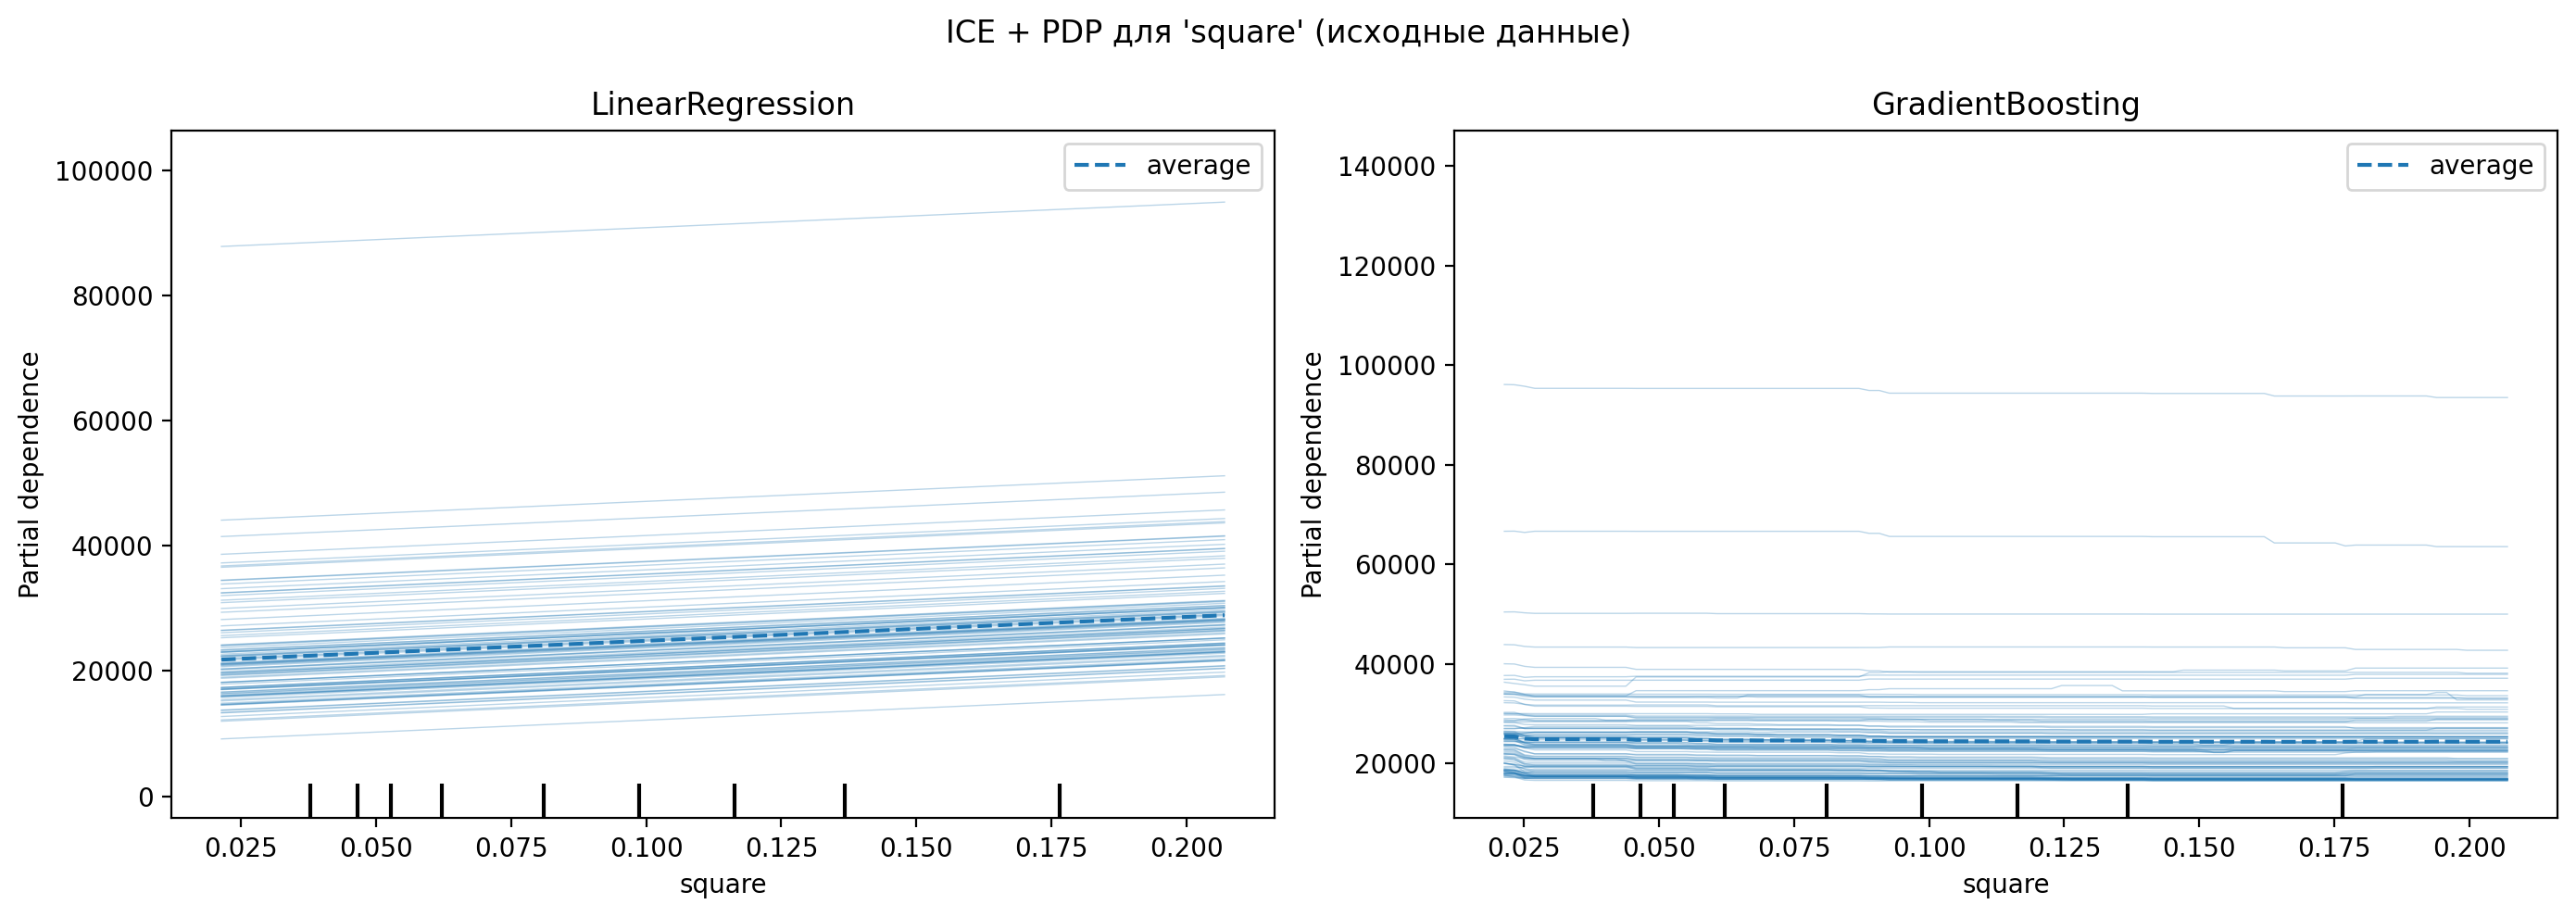

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("ICE + PDP для 'square' (исходные данные)")
for ax, model, name in zip(axes, [lr_mm2, gb_mm2], ['LinearRegression', 'GradientBoosting']):
    PartialDependenceDisplay.from_estimator(
        model, X_train_mm, [feature_idx],
    kind='both', subsample=100, random_state=42, ax=ax
    )
    ax.set_title(name)
plt.tight_layout()
plt.show()

LR с исходными: PDP идеально прямая линия вверх, ICE линии строго паралельны ->
Модель считает что площадь влияет на все квартиры одинаково, просто сдвиагет предсказание ввеох / вниз (это ограничения линейной модели, а не истина)

GB с исходными: PDP нелинейная - пологая в начале. ICE кривые расходятся, изредка пересекается, но слабо, но в целом примерно на одном уровне -> цена зависит от других признаков

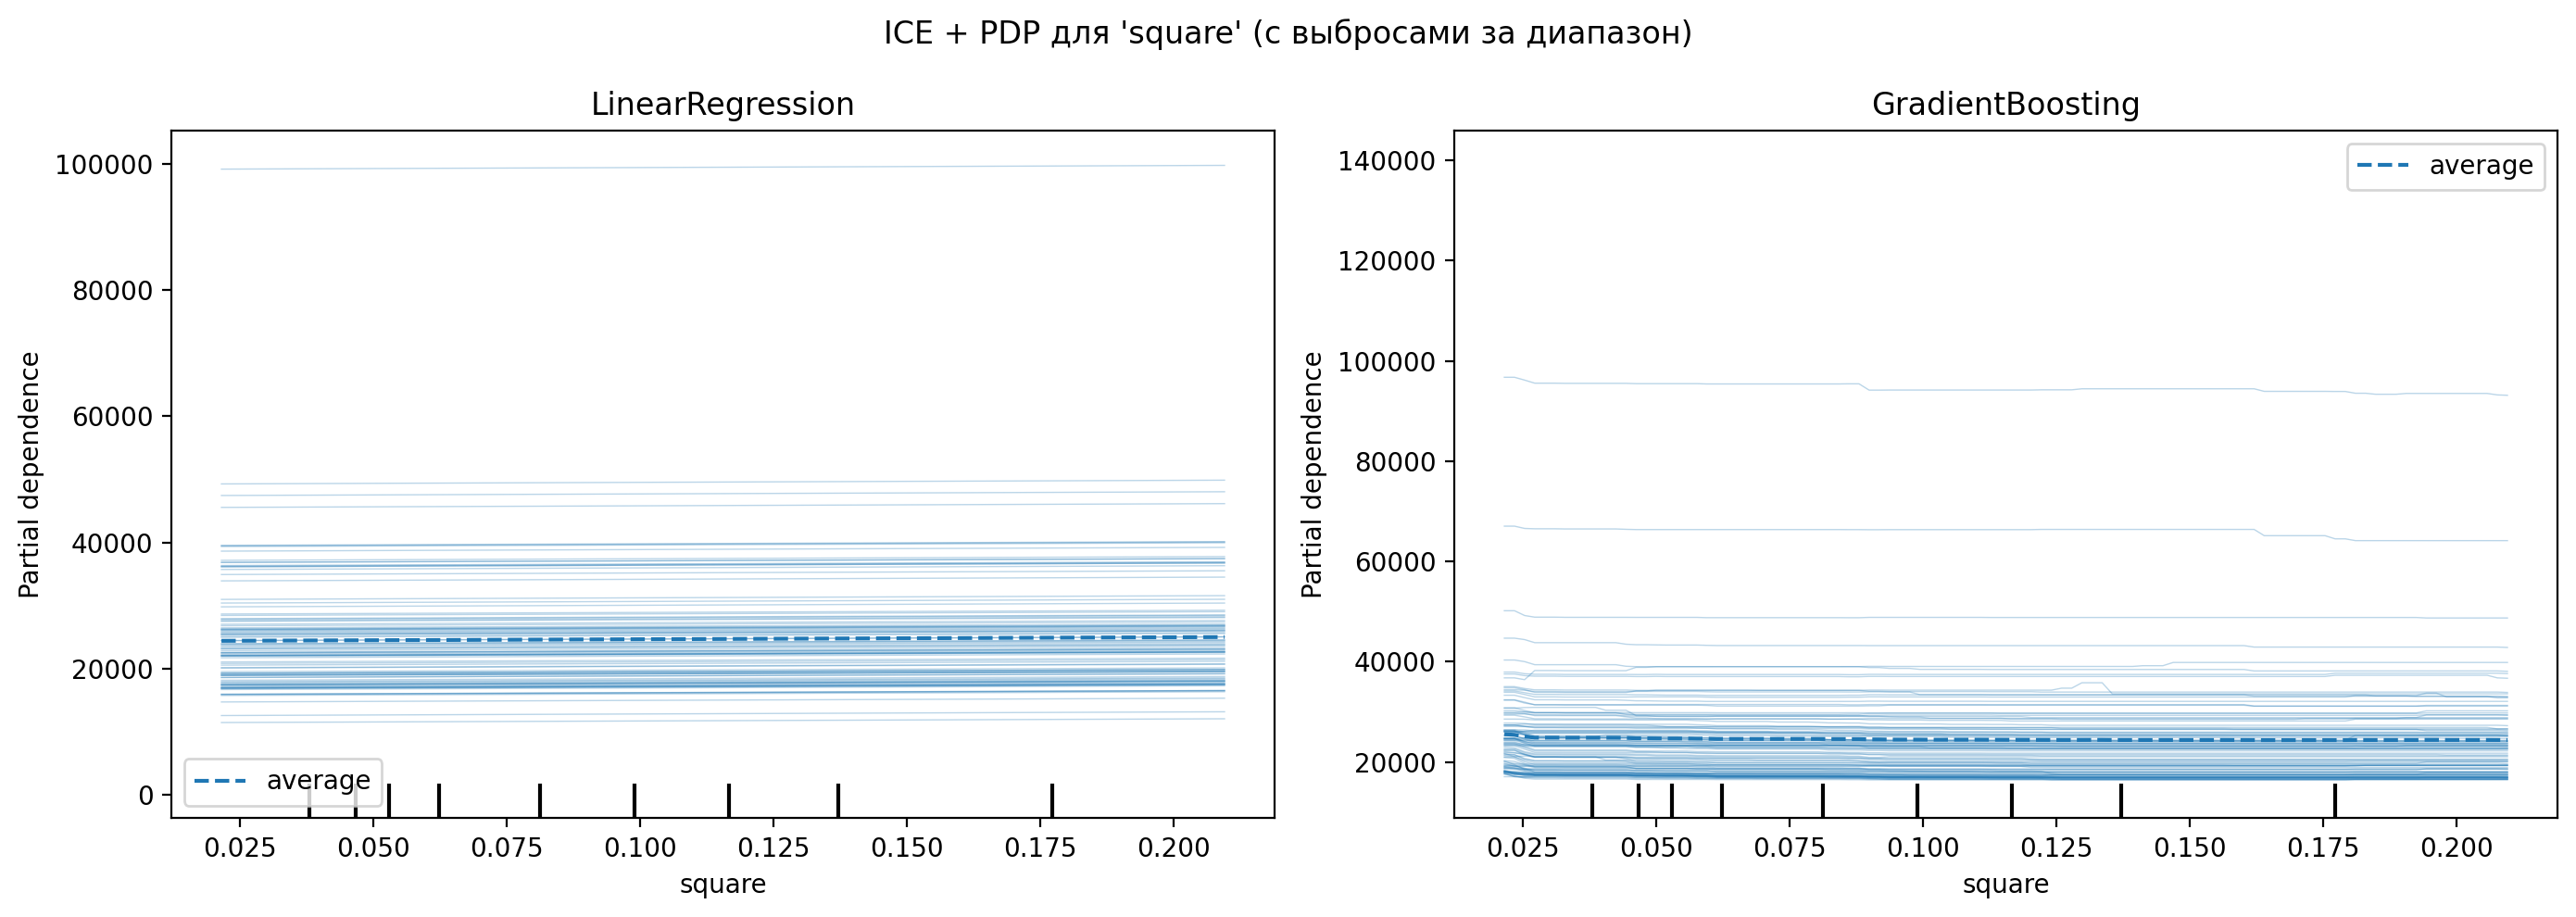

In [42]:
# С выбросами за пределы [0, 1]
X_train_out = X_train_mm.copy()
outlier_idx = X_train_out.sample(50, random_state=42).index
X_train_out.loc[outlier_idx, feature] = np.random.uniform(1.5, 3.0, 50)

lr_out = LinearRegression()
lr_out.fit(X_train_out, y_train)
gb_out = GradientBoostingRegressor(max_depth=5, random_state=42)
gb_out.fit(X_train_out, y_train)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("ICE + PDP для 'square' (с выбросами за диапазон)")
for ax, model, name in zip(axes, [lr_out, gb_out], ['LinearRegression', 'GradientBoosting']):
    PartialDependenceDisplay.from_estimator(
        model, X_train_out, [feature_idx],
        kind='both', subsample=100, random_state=42, ax=ax
    )
    ax.set_title(name)
plt.tight_layout()
plt.show()

LR + выбросы: 
Изменился наколн - почти прямая линяя. - нет влияния, но это абсурдные предсказания

GB + выбросы: 
в зоне [0,1] похоже на исходное, криваяя и так "замёрзла", но по идее после [0,1] этот эффект должен быть ещё более явным, хотя из-за масштаба этого не видно. По теории после 1 просто поподаем к крайний лист

#### Что будет если признаки выйдут за диапазон?
LinearRegression - экстраполирует линейно за пределы обучающего диапазона -> предсказания могут быть абсурдными, но модель не "знает" об этом
GradientBoosting - "замерзает" на крайнем значении -> деревья не умеют экстраполировать, просто попадают в крайний лист


## Задание 3. 1 балл
Выберите 20 объектов из тестовой выборки.
Для каждого объекта из выбранного набора построим траекторию изменения предсказания модели при постепенном изменении значения признака от его текущего значения к базовому значению (медиана или среднее по обучающей выборке).

**Алгоритм:**
1. Выбрать объект $x_i$ из тестовой выборки
2. Для интересующего признака $j$:
   - Текущее значение: $x_{i,j}$
   - Базовое значение: $x_{base,j}$ (медиана или среднее по обучающей выборке)
3. Построить линейную интерполяцию между $x_{i,j}$ и $x_{base,j}$ с $n$ шагами
4. Для каждого шага интерполяции:
   - Заменить значение признака $j$ в объекте $x_i$ на значение из интерполяции
   - Вычислить предсказание модели для модифицированного объекта
5. Построить график траектории


Задание 3.1 (*) 1 балл: проанализируйте также еще один признак

хотим увидеть, что для одних квартир площедь важна, для других нет.
Тот же ICE, но не по всей [min, max], а по траектории

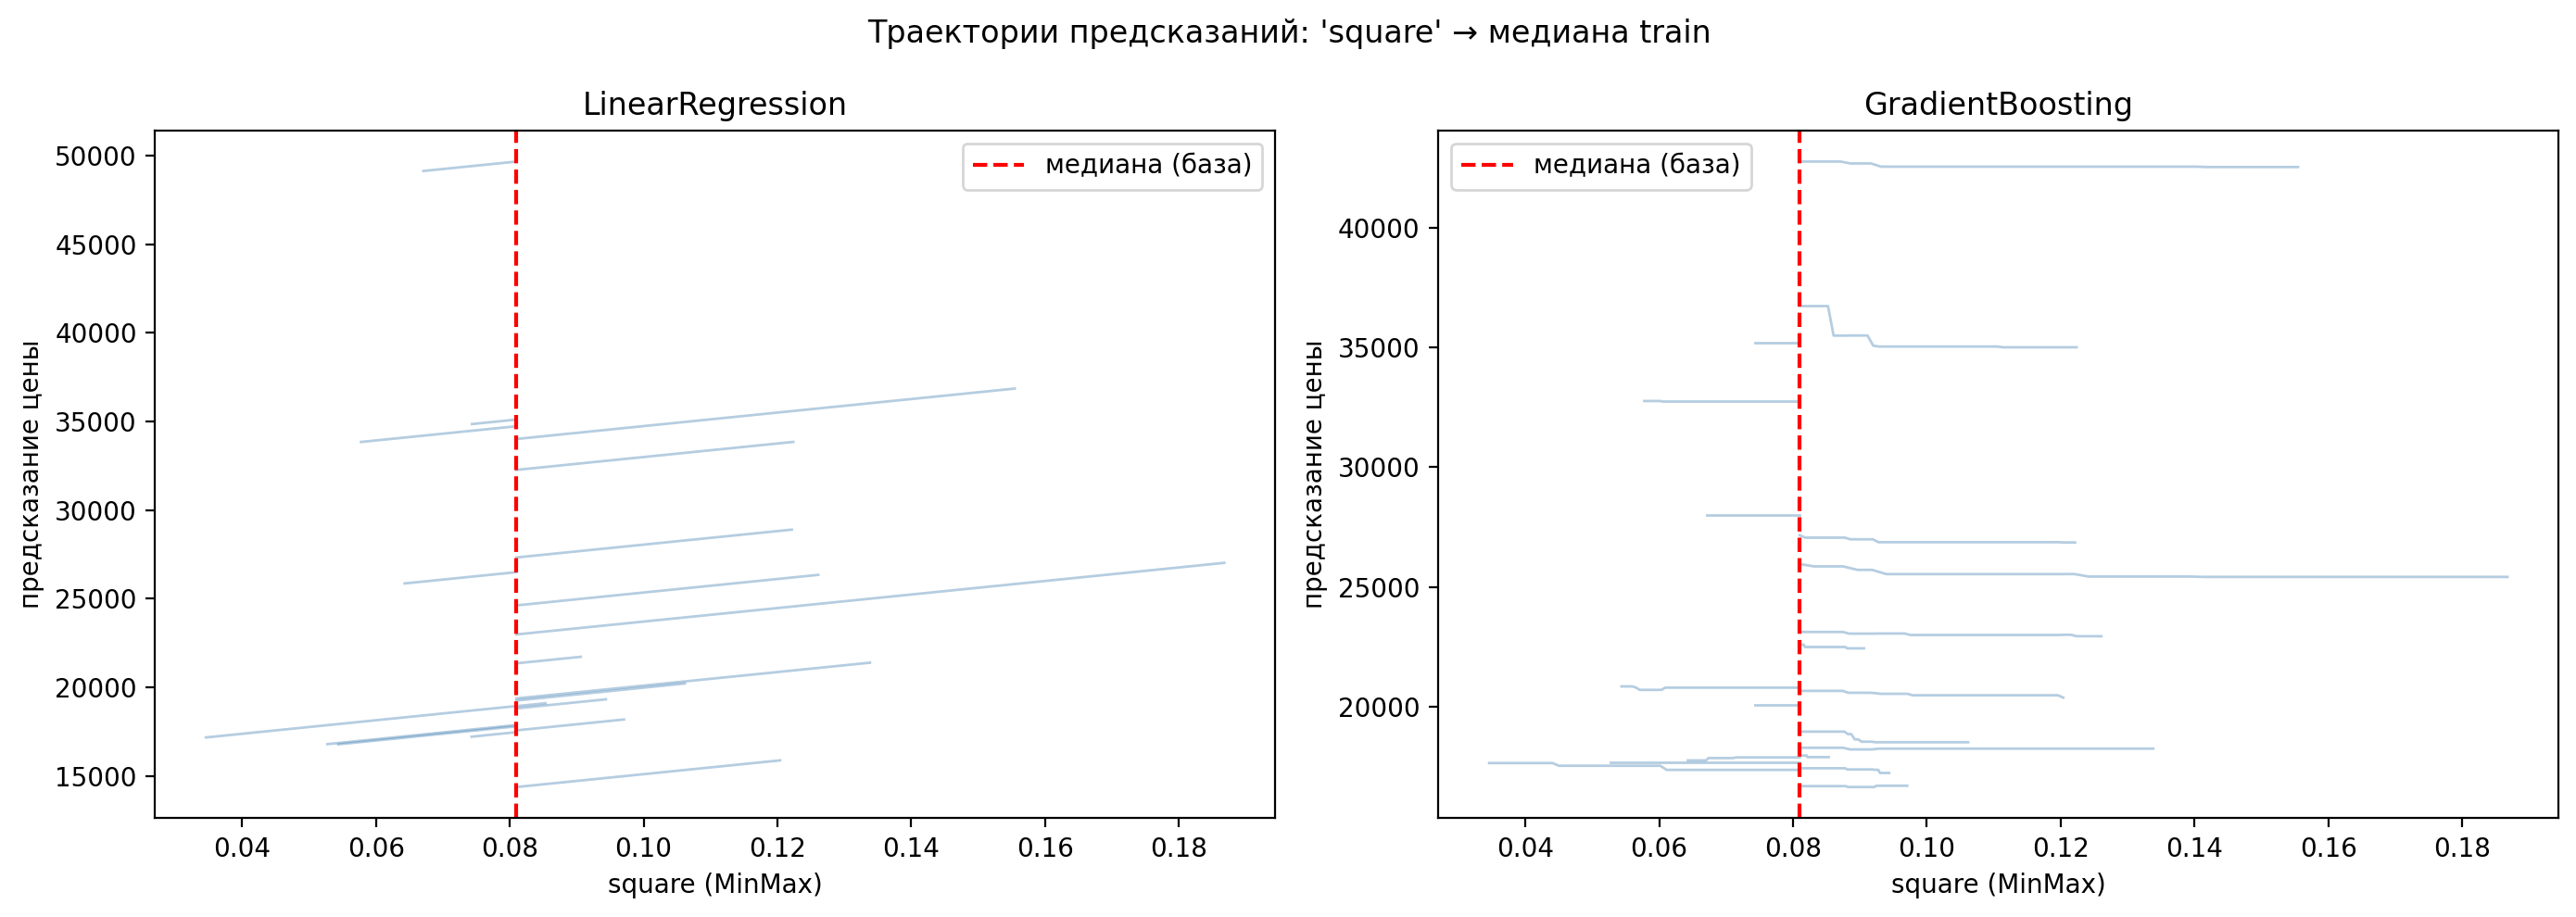

In [50]:
feature = 'square'
base_value = X_train_mm[feature].median()
sample = X_test_mm.sample(20, random_state=42).reset_index(drop=True)

def plot_trajectories(ax, model, name, sample, feature, base_value, n_steps=50):
    for i in range(len(sample)):
        obj = sample.iloc[i].copy()
        steps = np.linspace(obj[feature], base_value, n_steps)
        preds = [] 
        for v in steps:
            obj[feature] = v
            preds.append(model.predict(obj.values.reshape(1, -1))[0])
        ax.plot(steps, preds, alpha=0.4, linewidth=1, color='steelblue')
    ax.axvline(base_value, color='red', linestyle='--', linewidth=1.5, label='медиана (база)')
    ax.set_title(name)
    ax.set_xlabel(f'{feature} (MinMax)')
    ax.set_ylabel('предсказание цены')
    ax.legend()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"Траектории предсказаний: '{feature}' → медиана train")
plot_trajectories(axes[0], lr_mm2, 'LinearRegression', sample, feature, base_value)
plot_trajectories(axes[1], gb_mm2, 'GradientBoosting', sample, feature, base_value)
plt.tight_layout()
plt.show()


#### Чтоо видим?

LR: все 20 линий прямые и параллельные -> модель добавляет одинаковый прирост за единицу прироста площади

GB: кривые расходятся - для разных объектов эффект разный. то есть такая нелинейность, а именно бустинг учитывает взаимодействие площади с другими признаками

## Задание 4 (1 балл). ALE
Постройте ALE по обеим моделям, используя pyALE. Подберите размер сетки так, чтобы получить доверительные интервалы. Проанализируйте полученный график. Каковы получились доверительные интервалы? Почему они различны для моделей?

P.s. Сетку значений стройте для исходного признака.

PyALE._ALE_generic:INFO: Continuous feature detected.
PyALE._ALE_generic:INFO: Continuous feature detected.


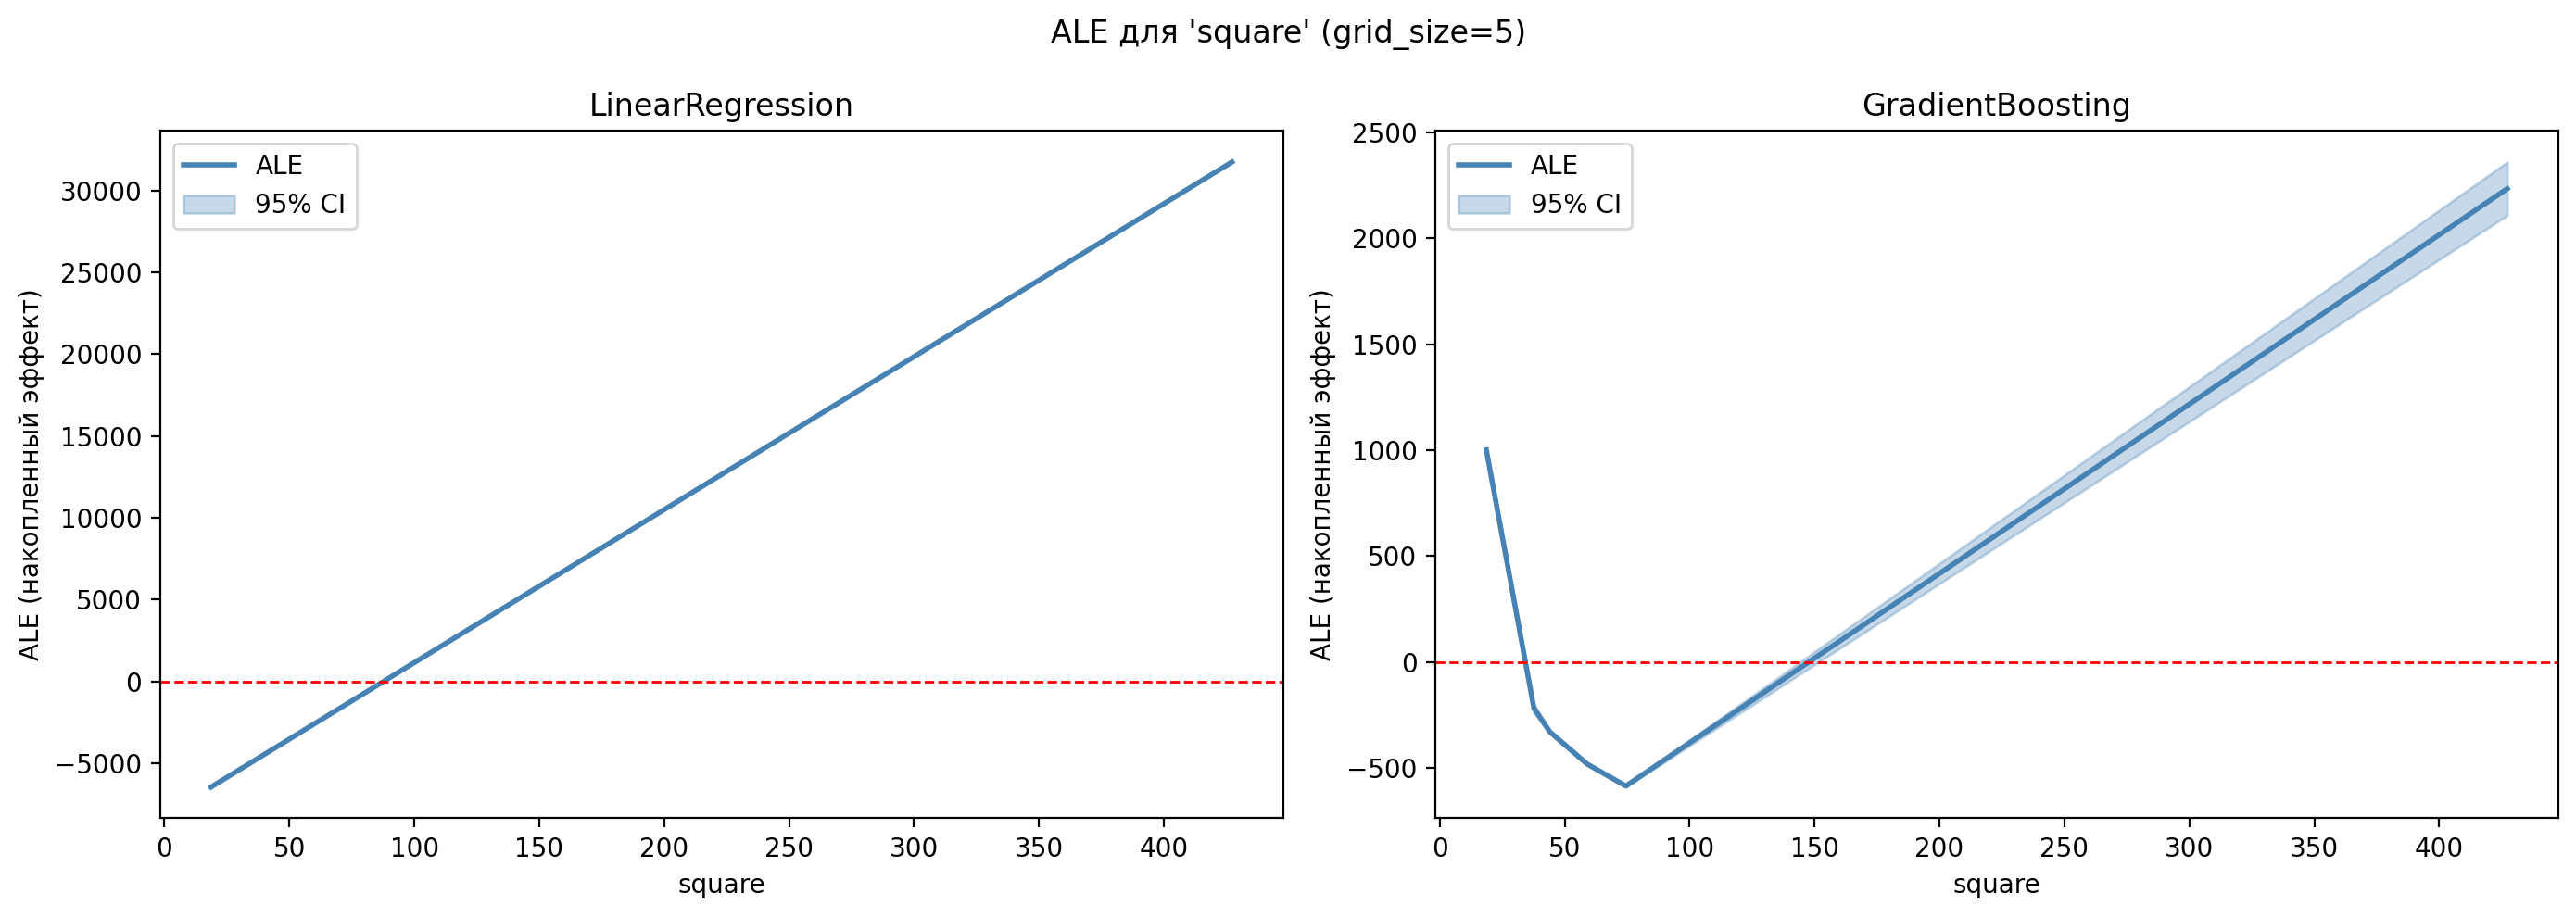

PyALE._ALE_generic:INFO: Continuous feature detected.
PyALE._ALE_generic:INFO: Continuous feature detected.


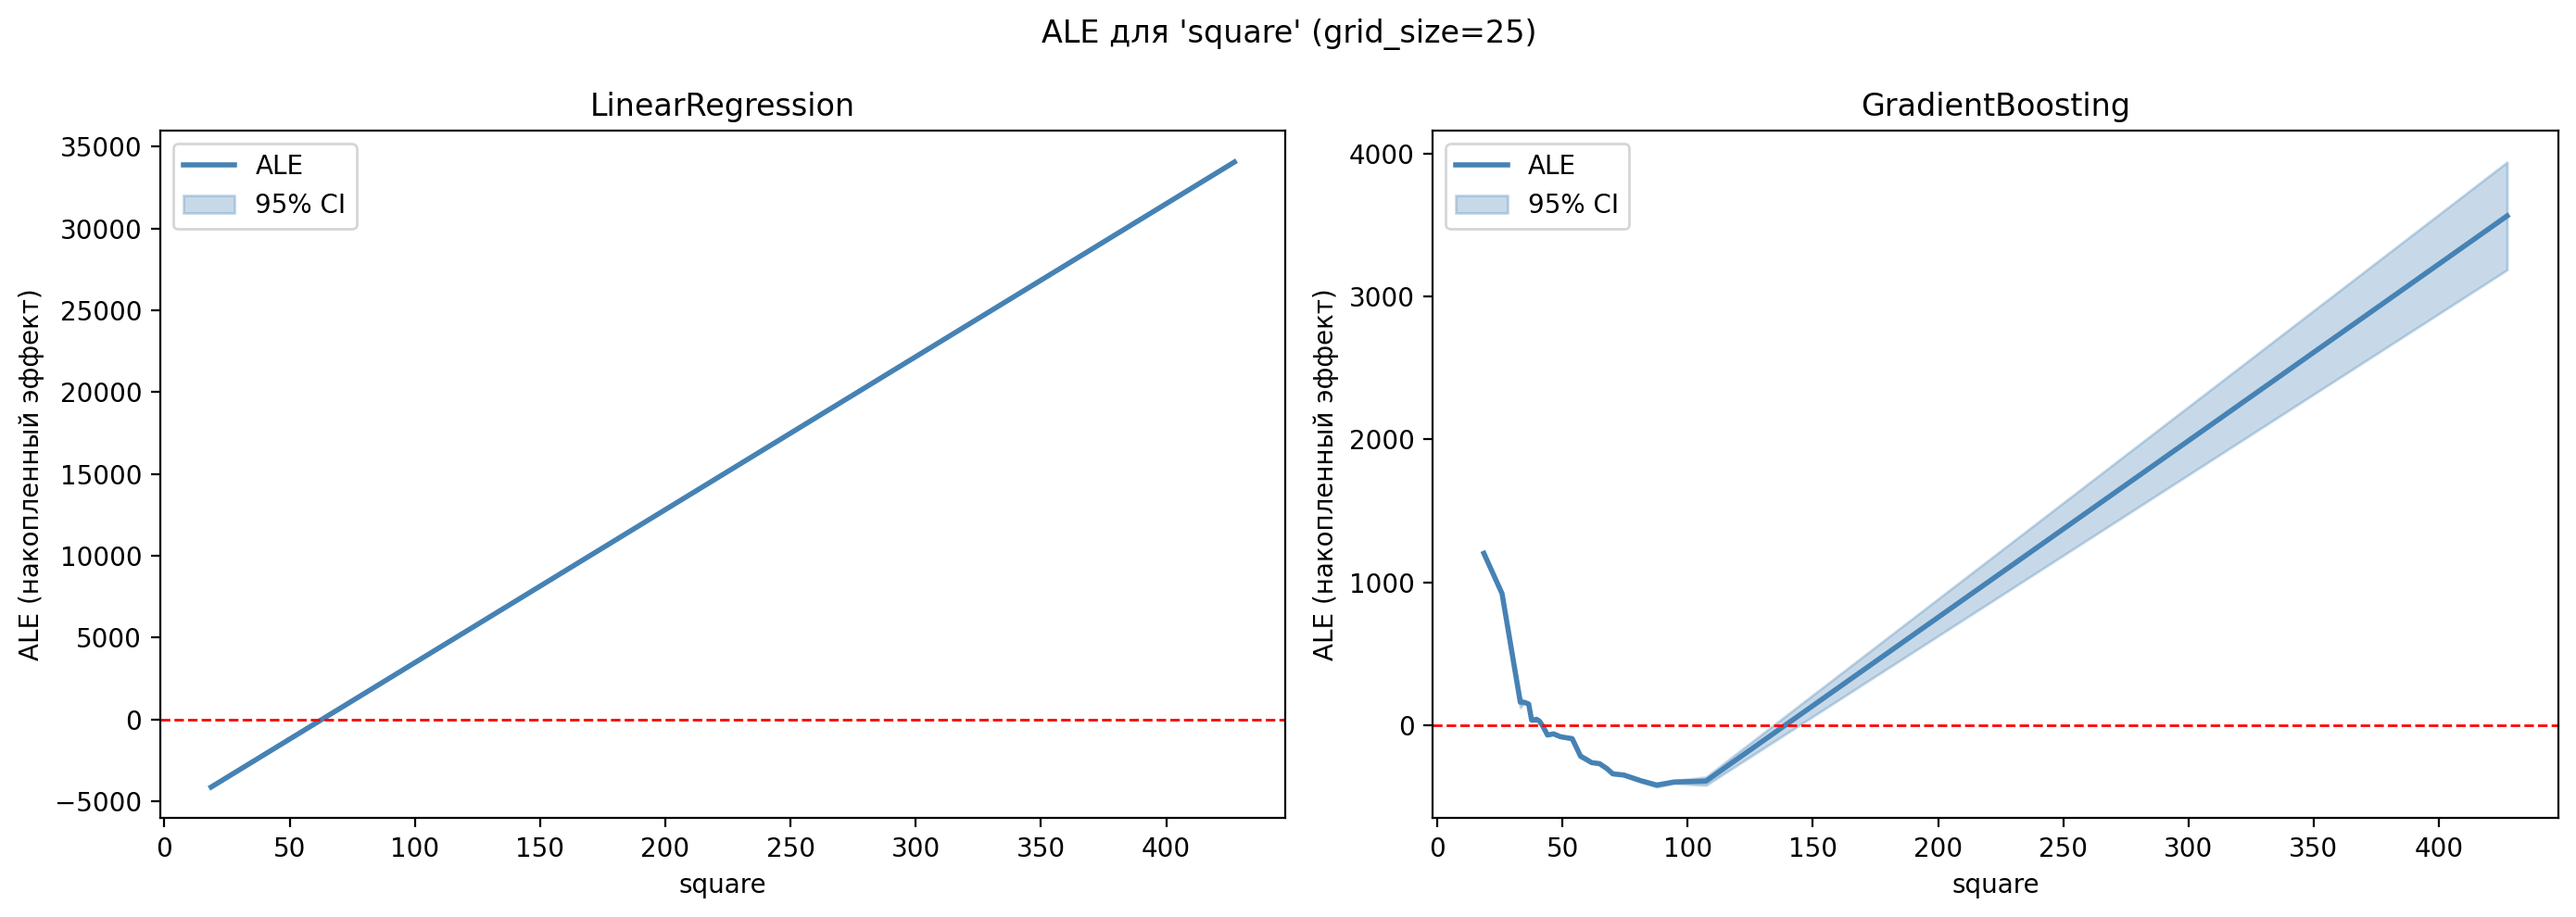

PyALE._ALE_generic:INFO: Continuous feature detected.
PyALE._ALE_generic:INFO: Continuous feature detected.


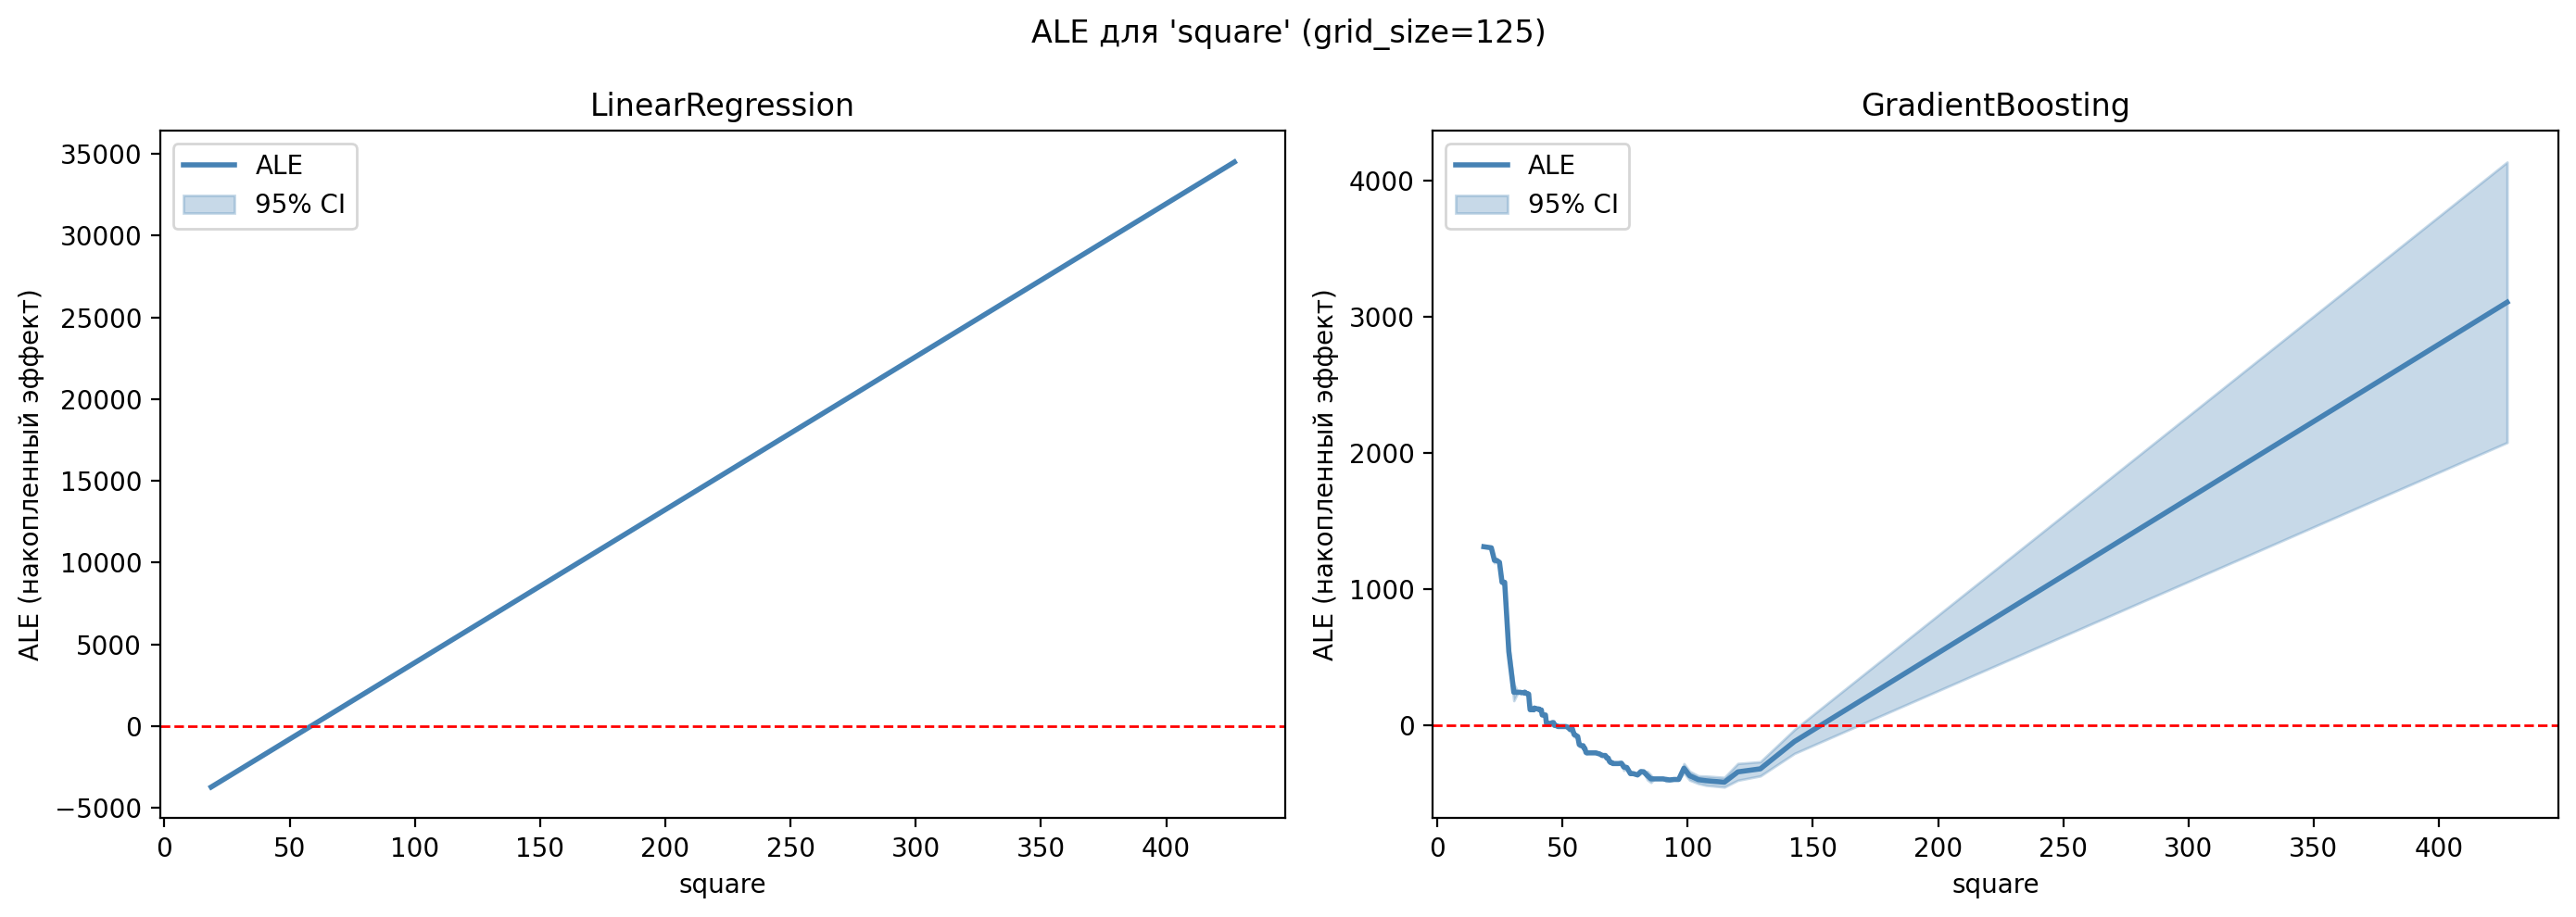

In [57]:
feature = 'square'

def plot_ale(grid_size):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"ALE для '{feature}' (grid_size={grid_size})")
    for ax, model, name in zip(axes, [lr, gb], ['LinearRegression', 'GradientBoosting']):
        ale_eff = ale(
            X=X_train, model=model, feature=[feature],
            grid_size=grid_size, include_CI=True, C=0.95, plot=False
        )
        ax.plot(ale_eff.index, ale_eff['eff'], color='steelblue', linewidth=2, label='ALE')
        ax.fill_between(ale_eff.index, ale_eff['lowerCI_95%'], ale_eff['upperCI_95%'],
                        alpha=0.3, color='steelblue', label='95% CI')
        ax.axhline(0, color='red', linestyle='--', linewidth=1)
        ax.set_title(name)
        ax.set_xlabel(feature)
        ax.set_ylabel('ALE (накопленный эффект)')
        ax.legend()
    plt.tight_layout()
    plt.show()

# for grid_size in [10, 25, 50, 100]:
for grid_size in [5, 25, 125]:
    plot_ale(grid_size)


LR: ALE - прямая линия, эффект строго линейный. CI фактически нет, ведь
модель детерминирована, предсказания не варьируются внутри ячейки.

GB: ALE нелинейная: пик в начале (маленькие квартиры ~20м² дороже (наверное из-за расположения где-нибудь в центре Москве, где популярный квартиры студии, но цены высокие)),
затем падение до ~150м², потом рост. CI шире — модель нелинейна, 
внутри ячейки предсказания варьируются.

grid_size: чем больше ячеек → меньше объектов в каждой → шире CI.
При grid_size=5,10,25 интервалы узкие (много объектов в ячейке),
при grid_size=100,125 заметно ширt


## Задание 5:  Permutation Importance (2 балла)
Постройте Permutation importances по обеим моделям, используя sklearn.

Поэкспериментируйте с числом перестановок.

Проанализируйте полученные коэффициенты. Как они меняются от количества перестановок? Как меняются std коэффициентов?



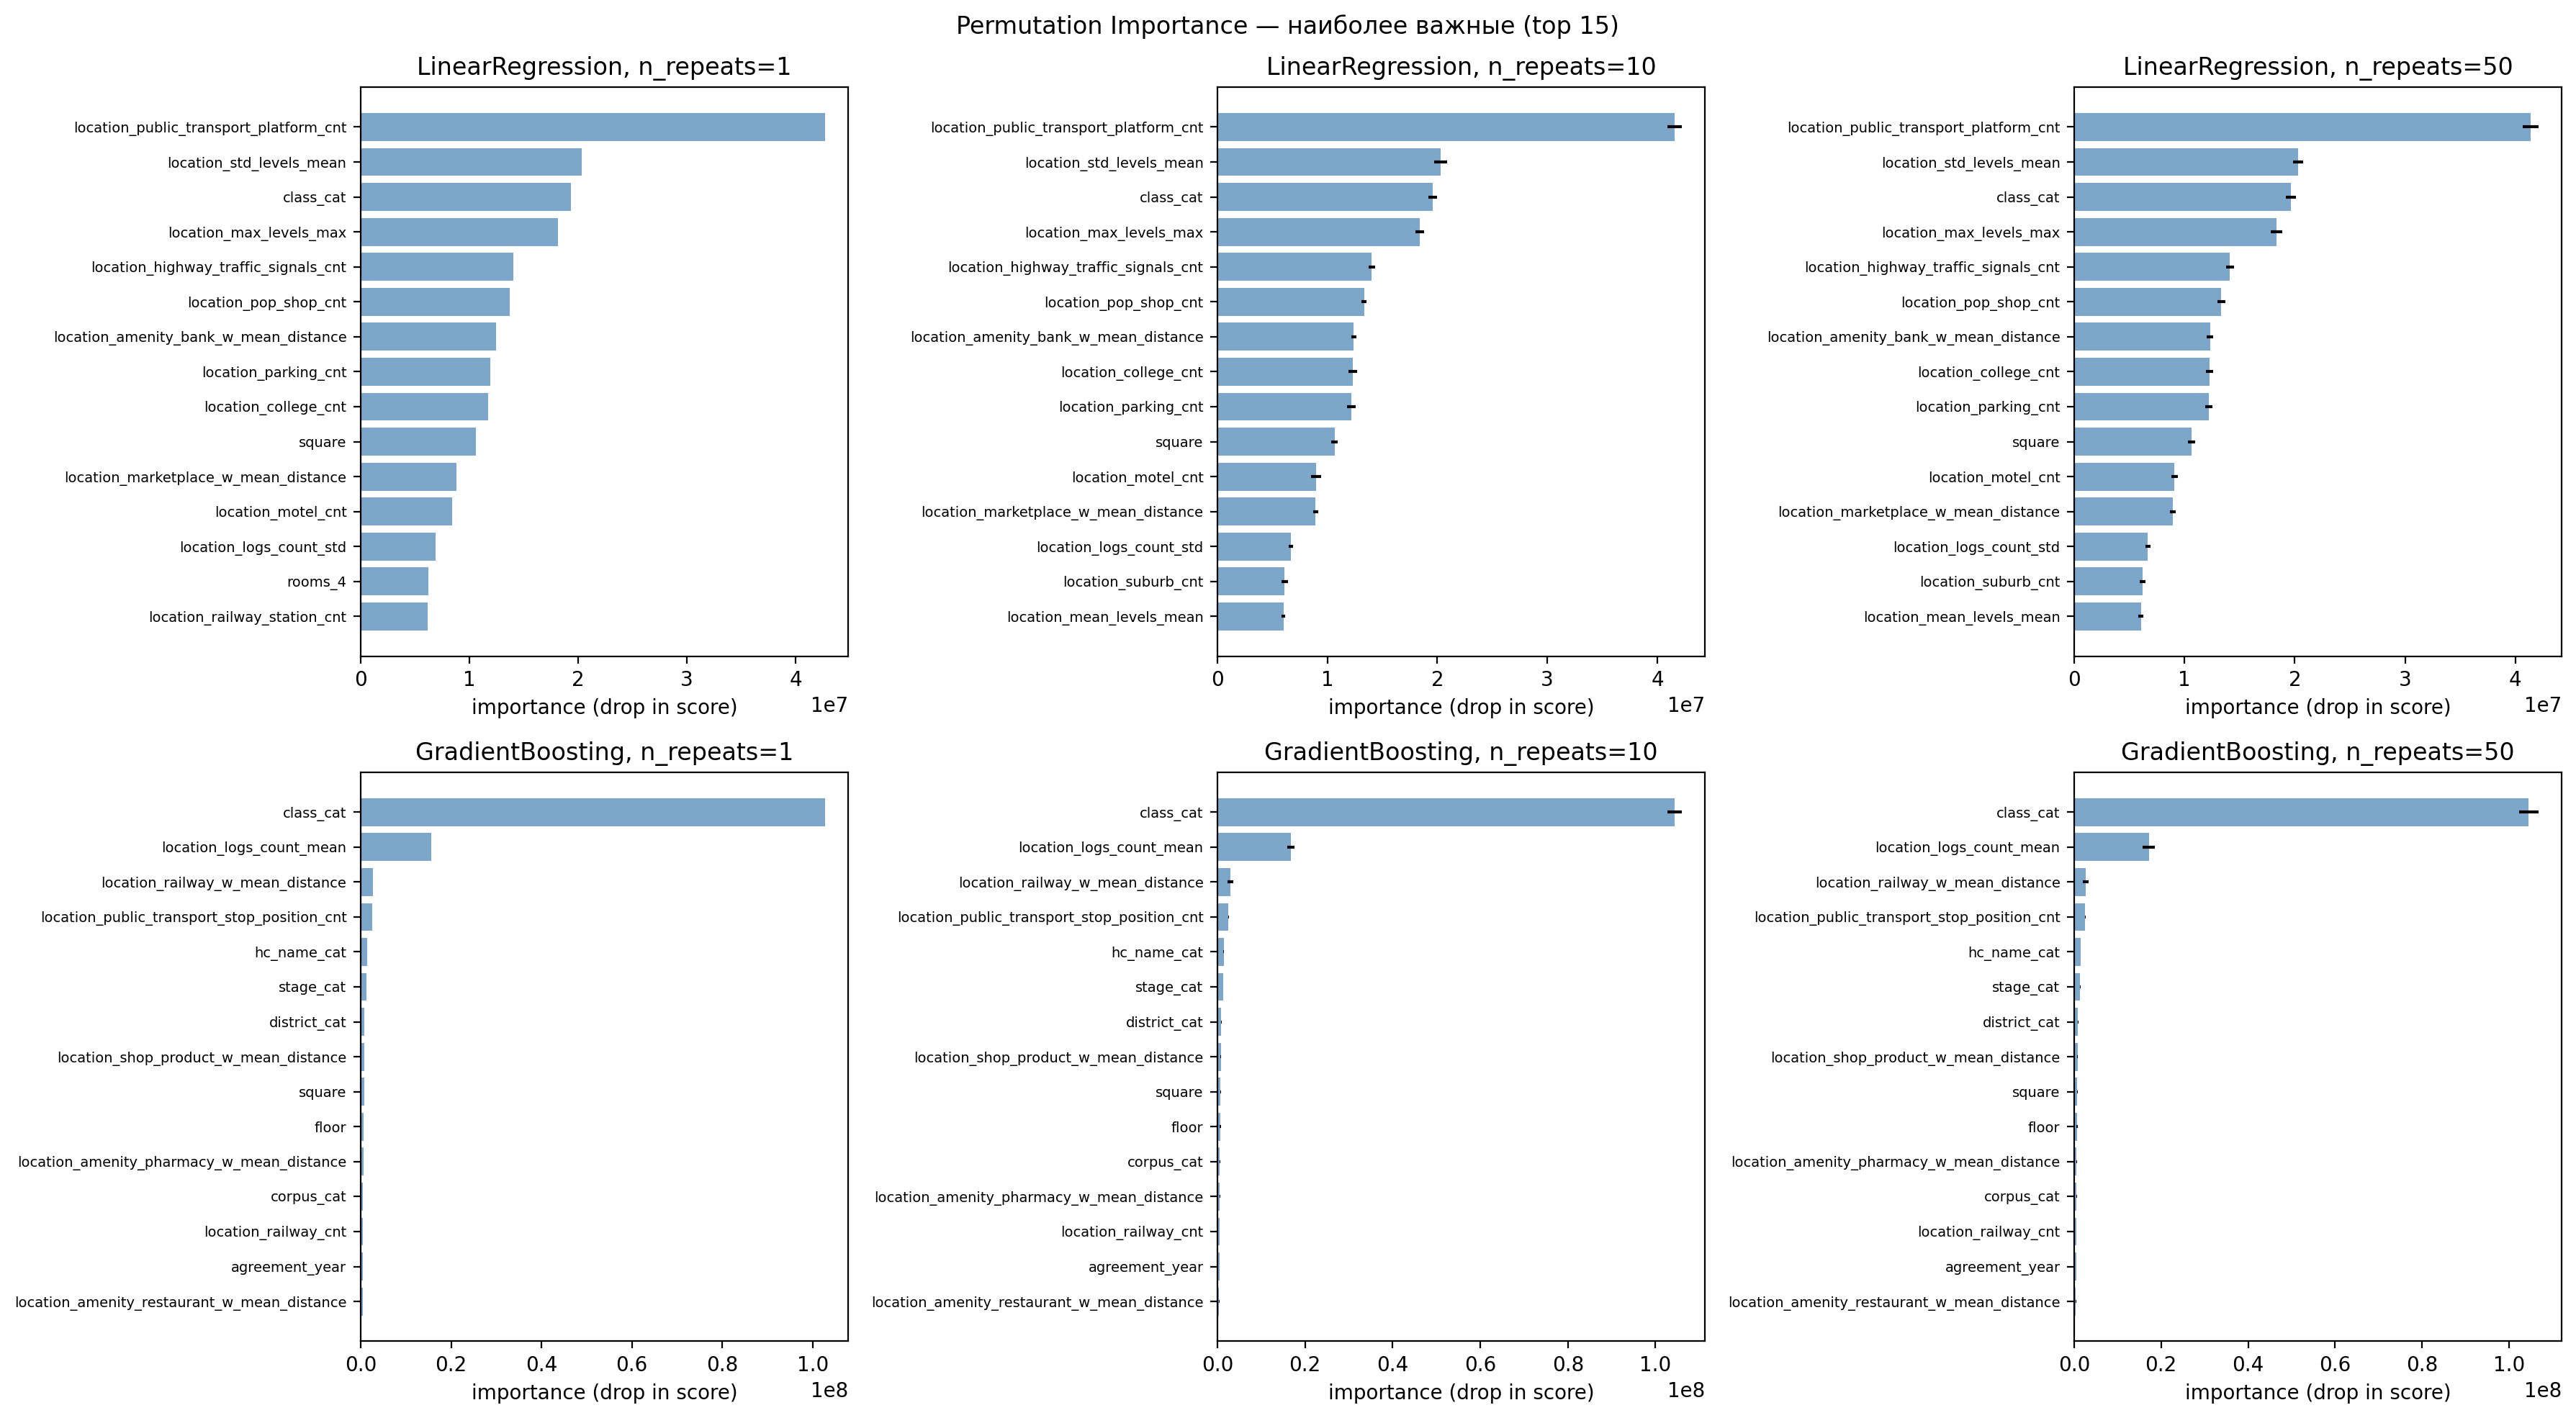

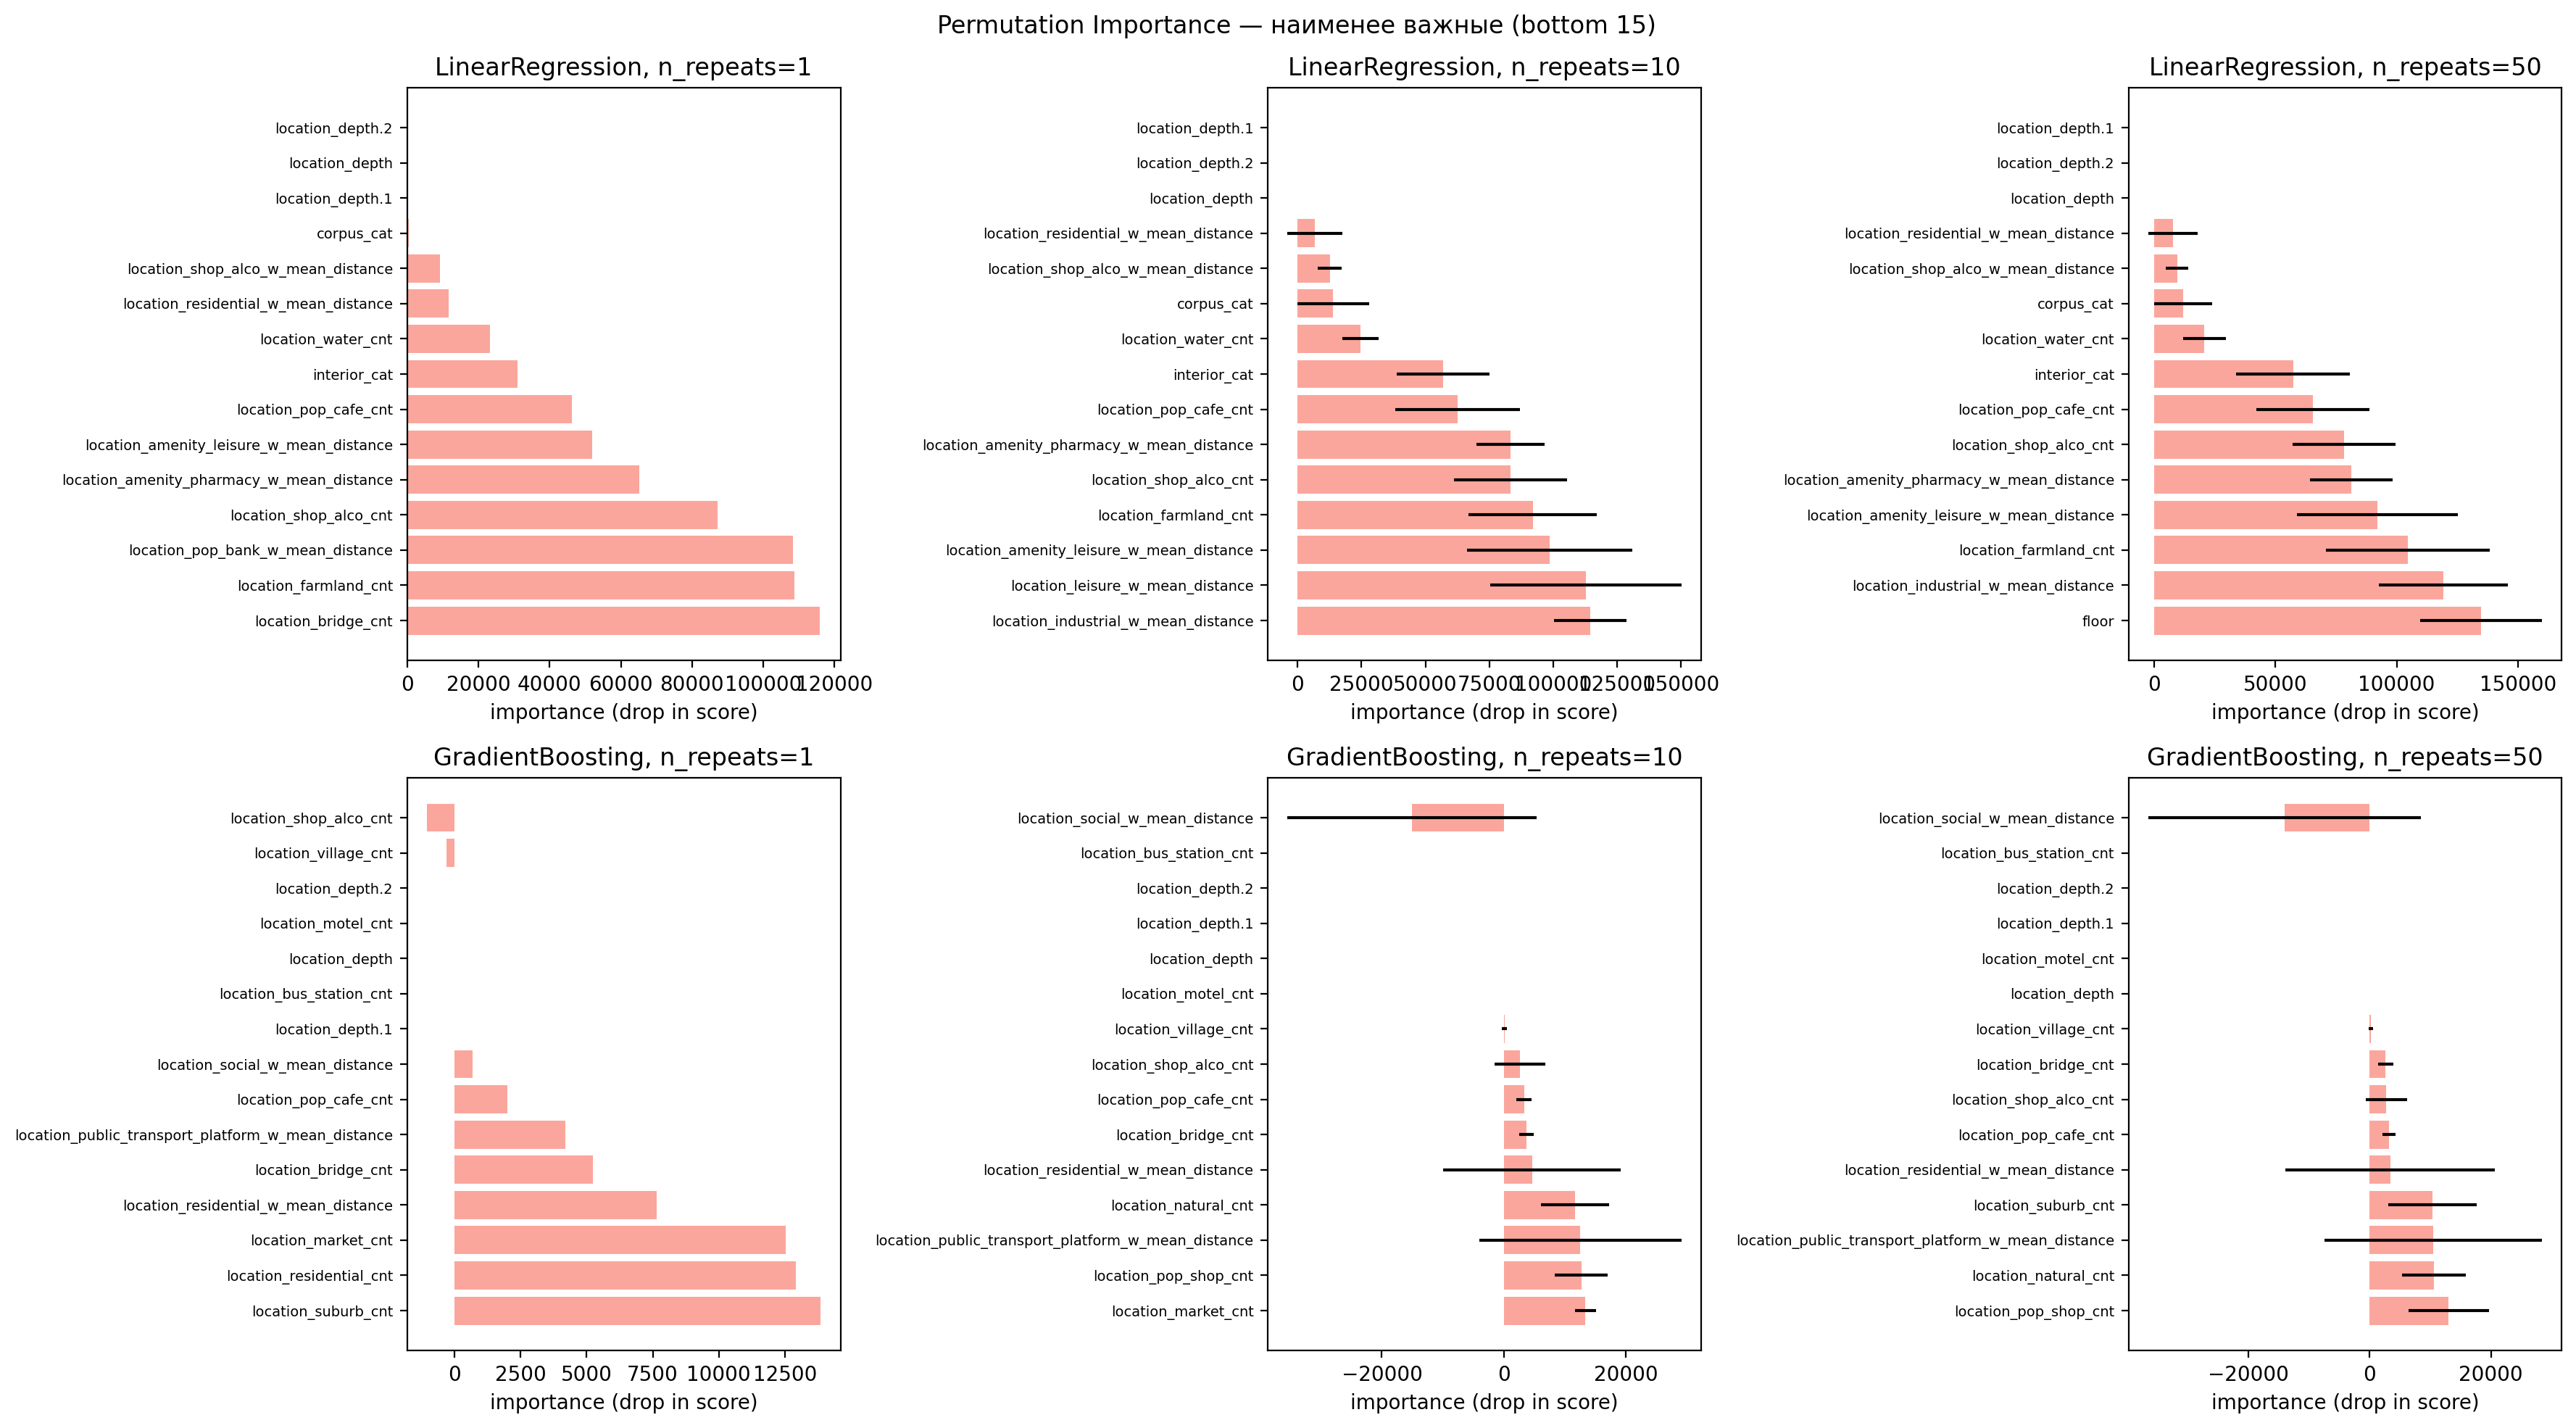

In [62]:
top_n = 15

def plot_pi(title, most_important=True):
    color = 'steelblue' if most_important else 'salmon'
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(title)
    
    for row, (model, name) in enumerate([(lr, 'LinearRegression'), (gb, 'GradientBoosting')]):
        for col, n_repeats in enumerate([1, 10, 50]):
            pi = permutation_importance(model, X_test, y_test,
                                        n_repeats=n_repeats, random_state=42,
                                        scoring='neg_mean_squared_error')
            sorted_idx = np.argsort(pi.importances_mean)
            idx = sorted_idx[::-1][:top_n] if most_important else sorted_idx[:top_n]
            
            ax = axes[row][col]
            ax.barh(range(top_n), pi.importances_mean[idx][::-1],
                    xerr=pi.importances_std[idx][::-1], color=color, alpha=0.7)
            ax.set_yticks(range(top_n))
            ax.set_yticklabels(X_test.columns[idx][::-1], fontsize=7)
            ax.set_title(f"{name}, n_repeats={n_repeats}")
            ax.set_xlabel("importance (drop in score)")
            
    plt.tight_layout()
    plt.show()

plot_pi("Permutation Importance - наиболее важные (top 15)", most_important=True)
plot_pi("Permutation Importance - наименее важные (bottom 15)", most_important=False)

Наиболее важные:
- LR: location_public_transport_platform_cnt — транспортная доступность
- GB: class_cat с огромным отрывом — класс жилья определяет цену

При n_repeats=1 std=0 (одна перестановка — нет разброса).
При n_repeats=10,50 std стабилизируется — оценка надёжнее.

Наименее важные:
- location_depth, location_depth.1, location_depth.2 — importance=0,
  это дублированные признаки, модели их игнорируют
- У GB некоторые признаки дают отрицательный importance —
  после перемешки модель стала чуть лучше, значит признак вносил шум

## Задание 5: Feature Importance (2 балла)
Пусть важность - это MAPE для тестовых данных. Проведите анализ только для бустинга

Идея перестановочной важности представляет собой частный случай важности при помощи внесения возмущений в признак. Примеры возмущений:
1) внесение случайного шума
2) зануление признака
3) сдвиг признака к его базовому значению и оценка траектории изменения прогнозов или качества модели 

Примем за базовое значение (${base}$)медиану признака и будем сдвигать исходный признак к медианному с некоторым коэффициентом $\beta$:
$x_j^\beta = (1- \beta)x_j + \beta {base}$

Реализуйте это возмущение. Как меняются важности при разных $\beta$?

Постройте графики важности и сравните важности с permutation importance. Используйте только числовые признаки. При этом медиану стоит считать на тренировочном наборе, а важность как разницу MAPE на тестовой выборке. Чем больше разница, тем важнее признак. 


Сравните результаты методов. Какие признаки наиболее важны? Есть ли различия между методами? В чём могут быть причины различий?

In [65]:
num_features = X_train.select_dtypes(include='number').columns.tolist()
train_medians = X_train[num_features].median()

base_mape = mape(y_test.values, gb.predict(X_test))

betas = [0.25, 0.5, 0.75, 1.0]
results = {beta: {} for beta in betas}

for feature in num_features:
    for beta in betas:
        # Здесь должен быть отступ ровно в 8 пробелов (2 уровня)
        X_perturbed = X_test.copy()
        X_perturbed[feature] = (1 - beta) * X_test[feature] + beta * train_medians[feature]
        results[beta][feature] = mape(y_test.values, gb.predict(X_perturbed)) - base_mape

top_features = pd.Series(results[1.0]).sort_values(ascending=False).head(15).index.tolist()

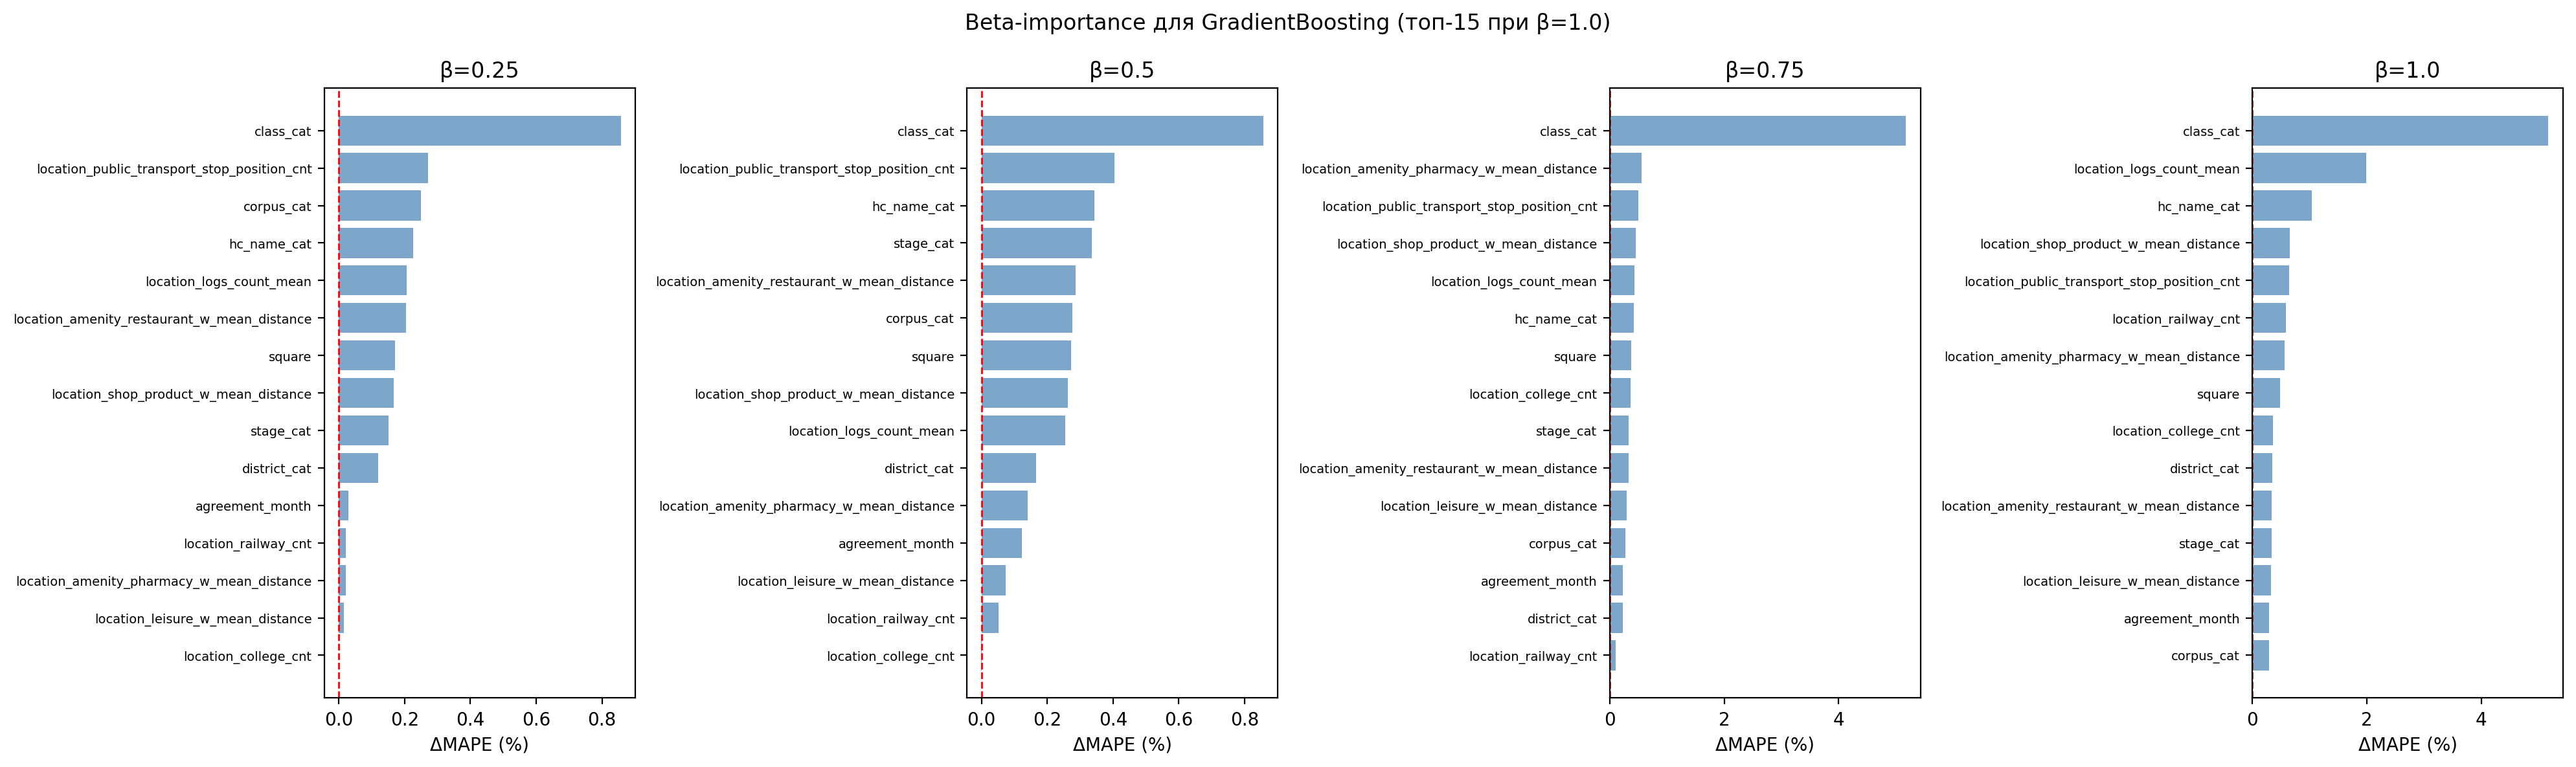

In [66]:
fig, axes = plt.subplots(1, len(betas), figsize=(20, 6))
fig.suptitle("Beta-importance для GradientBoosting (топ-15 при β=1.0)")

for ax, beta in zip(axes, betas):
    vals = pd.Series(results[beta])[top_features].sort_values()
    ax.barh(range(len(vals)), vals.values, color='steelblue', alpha=0.7)
    ax.set_yticks(range(len(vals)))
    ax.set_yticklabels(vals.index, fontsize=7)
    ax.set_title(f"β={beta}")
    ax.set_xlabel("ΔMAPE (%)")
    ax.axvline(0, color='red', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()

class_cat — самый важный признак при всех β: при β=0.25 ΔMAPE≈0.85%,
при β=1.0 ΔMAPE≈5.2%. Класс жилья критически важен для GB.

При малых β (0.25) важности уже заметны — даже небольшой сдвиг к медиане
ухудшает предсказание. При β=1.0 разрыв между признаками максимален.

Порядок признаков меняется при разных β: при β=0.25-0.5 второй по важности
location_public_transport_stop_position_cnt, при β=0.75-1.0 его вытесняет
location_logs_count_mean. Это значит: разные признаки по-разному реагируют
на степень возмущения — некоторые важны только при сильном сдвиге.

Сравнение с Permutation Importance: class_cat лидирует в обоих методах.
Beta-сдвиг мягче — не создаёт нереалистичных комбинаций признаков.


#  Задание 6. 2 балла. LIME.
Постройте интерпретацию признаков для нескольких примеров с помощью LIME. Можете использовать 
Оцените устойчивость реализации. Как влияет на коэффициенты количество сгенерированных точек? А выбор признаков (lasso/добавление фичей по порядку). А выбор ядра?

(*) Вы получите на 2 балла больше, если используете свою реализацию из задания семинарского ноутбука. В таком случае не забудьте добавить тесты для своей реализации. 



По умолчанию LIME использует гауссово ядро 

Проверим устойчивость на трёх параметрах: num_samples, feature_selection, kernel_width.


In [72]:
explainer = lime.lime_tabular.LimeTabularExplainer(
    X_train.values, feature_names=X_train.columns.tolist(),
    mode='regression', random_state=42
)
instance = X_test.iloc[0].values

print("num_samples → топ-3 (GB, объект #0):")
for n in [100, 500, 1000, 5000]:
    exp = explainer.explain_instance(instance, gb.predict, num_features=10, num_samples=n)
    print(f"\nnum_samples={n}")
    for feat, coef in exp.as_list()[:3]:
        print(f"  {feat:<60s} {coef:+.0f}")


num_samples → топ-3 (GB, объект #0):

num_samples=100
  27353.00 < class_cat <= 97865.00                             -10758
  location_car_rental_cnt <= 0.00                              -4168
  location_shop_alco_cnt <= 2.00                               +3610

num_samples=500
  27353.00 < class_cat <= 97865.00                             -11165
  location_logs_count_mean <= 21.52                            -1937
  location_motel_cnt <= 0.00                                   +1879

num_samples=1000
  27353.00 < class_cat <= 97865.00                             -12350
  location_motel_cnt <= 0.00                                   -4228
  location_car_rental_cnt <= 0.00                              -1638

num_samples=5000
  27353.00 < class_cat <= 97865.00                             -11793
  location_logs_count_mean <= 21.52                            -1797
  41.00 < district_cat <= 48.00                                -949


In [ ]:
print("feature_selection - топ-3 (GB, объект #0):")
for fs in ['auto', 'forward_selection', 'lasso_path']:
    exp_fs = lime.lime_tabular.LimeTabularExplainer(
        X_train.values, feature_names=X_train.columns.tolist(),
        mode='regression', random_state=42, feature_selection=fs
    )
    exp = exp_fs.explain_instance(instance, gb.predict, num_features=10, num_samples=1000)
    print(f"\nfeature_selection={fs}")
    for feat, coef in exp.as_list()[:3]:
        print(f"  {feat:<60s} {coef:+.0f}")


feature_selection → топ-3 (GB, объект #0):

feature_selection=auto
  27353.00 < class_cat <= 97865.00                             -11504
  agreement_month > 9.00                                       +1298
  location_college_cnt <= 0.00                                 -1285

feature_selection=forward_selection
  27353.00 < class_cat <= 97865.00                             -11521
  location_college_cnt <= 0.00                                 -1342
  agreement_month > 9.00                                       +1338

feature_selection=lasso_path
  27353.00 < class_cat <= 97865.00                             -11493
  location_college_cnt <= 0.00                                 -1406
  agreement_month > 9.00                                       +1310


In [ ]:
print("kernel_width -> топ-3 (GB, объект #0):")
for kw in [0.5, 3.0, 6.75, 20.0]:
    exp_kw = lime.lime_tabular.LimeTabularExplainer(
        X_train.values, feature_names=X_train.columns.tolist(),
        mode='regression', random_state=42, kernel_width=kw
    )
    exp = exp_kw.explain_instance(instance, gb.predict, num_features=10, num_samples=1000)
    print(f"\nkernel_width={kw}")
    for feat, coef in exp.as_list()[:3]:
        print(f"  {feat:<60s} {coef:+.0f}")


kernel_width → топ-3 (GB, объект #0):

kernel_width=0.5
  0.00 < location_commercial_cnt <= 1.00                       -0
  location_amenity_pharmacy_w_mean_distance > 0.98             -0
  location_public_transport_stop_position_w_mean_distance > 0.98 -0

kernel_width=3.0
  27353.00 < class_cat <= 97865.00                             -10746
  location_logs_count_mean <= 21.52                            -1280
  location_college_cnt <= 0.00                                 -1246

kernel_width=6.75
  27353.00 < class_cat <= 97865.00                             -11504
  agreement_month > 9.00                                       +1298
  location_college_cnt <= 0.00                                 -1285

kernel_width=20.0
  27353.00 < class_cat <= 97865.00                             -11513
  location_college_cnt <= 0.00                                 -1350
  agreement_month > 9.00                                       +1326


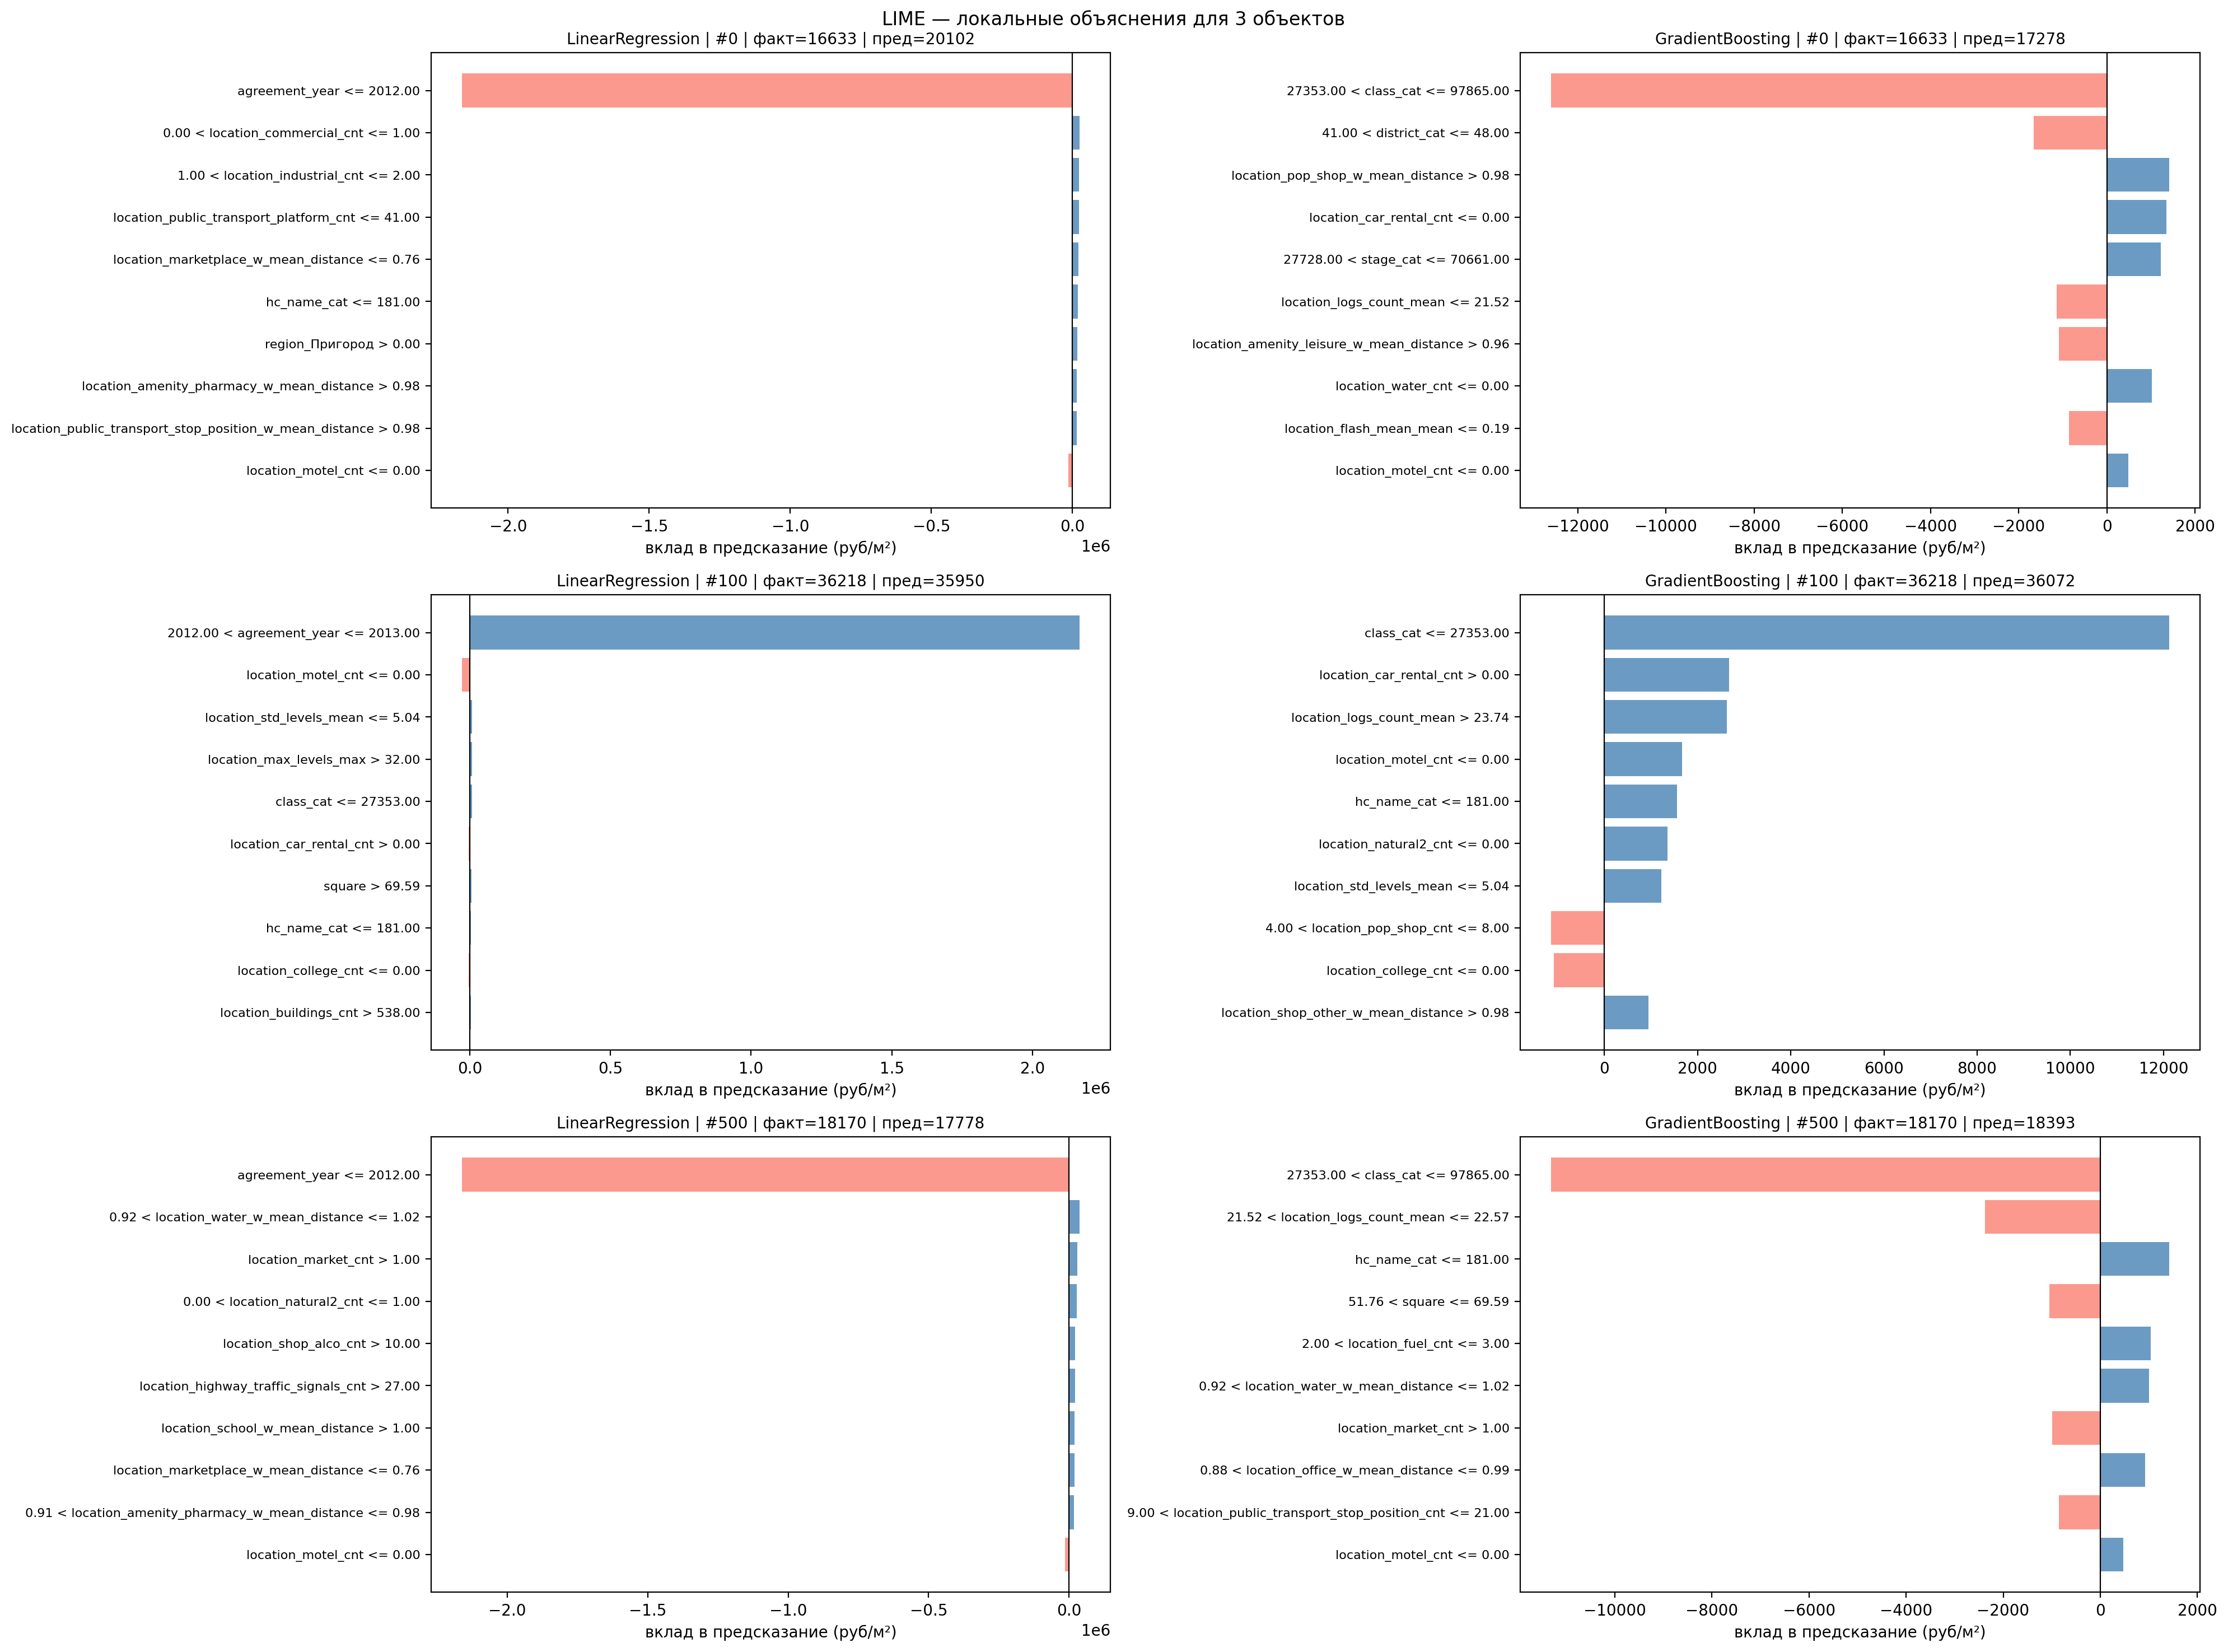

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(20, 15))
fig.suptitle("LIME - локальные объяснения для 3 объектов")

for row, idx in enumerate([0, 100, 500]):
    inst = X_test.iloc[idx].values
    true_val = y_test.iloc[idx]
    for col, (model, name) in enumerate([(lr, 'LinearRegression'), (gb, 'GradientBoosting')]):
        exp = explainer.explain_instance(inst, model.predict, num_features=10, num_samples=1000)
        pred = model.predict(inst.reshape(1, -1))[0]
        vals = exp.as_list()
        feats = [v[0] for v in vals]
        coefs = [v[1] for v in vals]
        colors = ['steelblue' if c > 0 else 'salmon' for c in coefs]
        ax = axes[row][col]
        ax.barh(range(len(coefs)), coefs[::-1], color=colors[::-1], alpha=0.8)
        ax.set_yticks(range(len(feats)))
        ax.set_yticklabels(feats[::-1], fontsize=8)
        ax.axvline(0, color='black', linewidth=0.8)
        ax.set_title(f"{name} | #{idx} | факт={true_val:.0f} | пред={pred:.0f}", fontsize=10)
        ax.set_xlabel("вклад в предсказание (руб/м²)")

plt.tight_layout()
plt.show()


## Задание 7. 1 балл. SHAP
Постройте локальный график с SHAP для объекта с индексом, равным вашему номеру в таблице курса на обеих моделях и сделайте выводы. 
## Задание 7.1 (*). 1 балл.  Shap и категориальные переменные.
Shap разлагает предсказание модели вблизи точки x на базовый уровень и сумму вкладов признаков: $ f(x) = base + \sum_i{\phi_i(x)}$. В случае one-hot вклад признака - это сумма вкладов dummy столбцов. Сравните вклады категориальных признаков до и после кодировки - так ли это? 


In [81]:
IDX = 27
instance = X_test.iloc[[IDX]]

explainer_lr = shap.LinearExplainer(lr, X_train)
sv_lr = explainer_lr(instance)

explainer_gb = shap.TreeExplainer(gb)
sv_gb = explainer_gb(instance)

print(f"объект #{IDX}: факт={y_test.iloc[IDX]:.0f} руб/м2")
print(f"  LR: base={sv_lr.base_values[0]:.0f}, сумма по фи={sv_lr.values[0].sum():+.0f}, pred={lr.predict(instance)[0]:.0f}")
print(f"  GB: base={sv_gb.base_values[0]:.0f}, сумма по фи={sv_gb.values[0].sum():+.0f}, pred={gb.predict(instance)[0]:.0f}")


объект #27: факт=15996 руб/м2
  LR: base=23179, сумма по фи=-5232, pred=17947
  GB: base=24624, сумма по фи=-7698, pred=16927


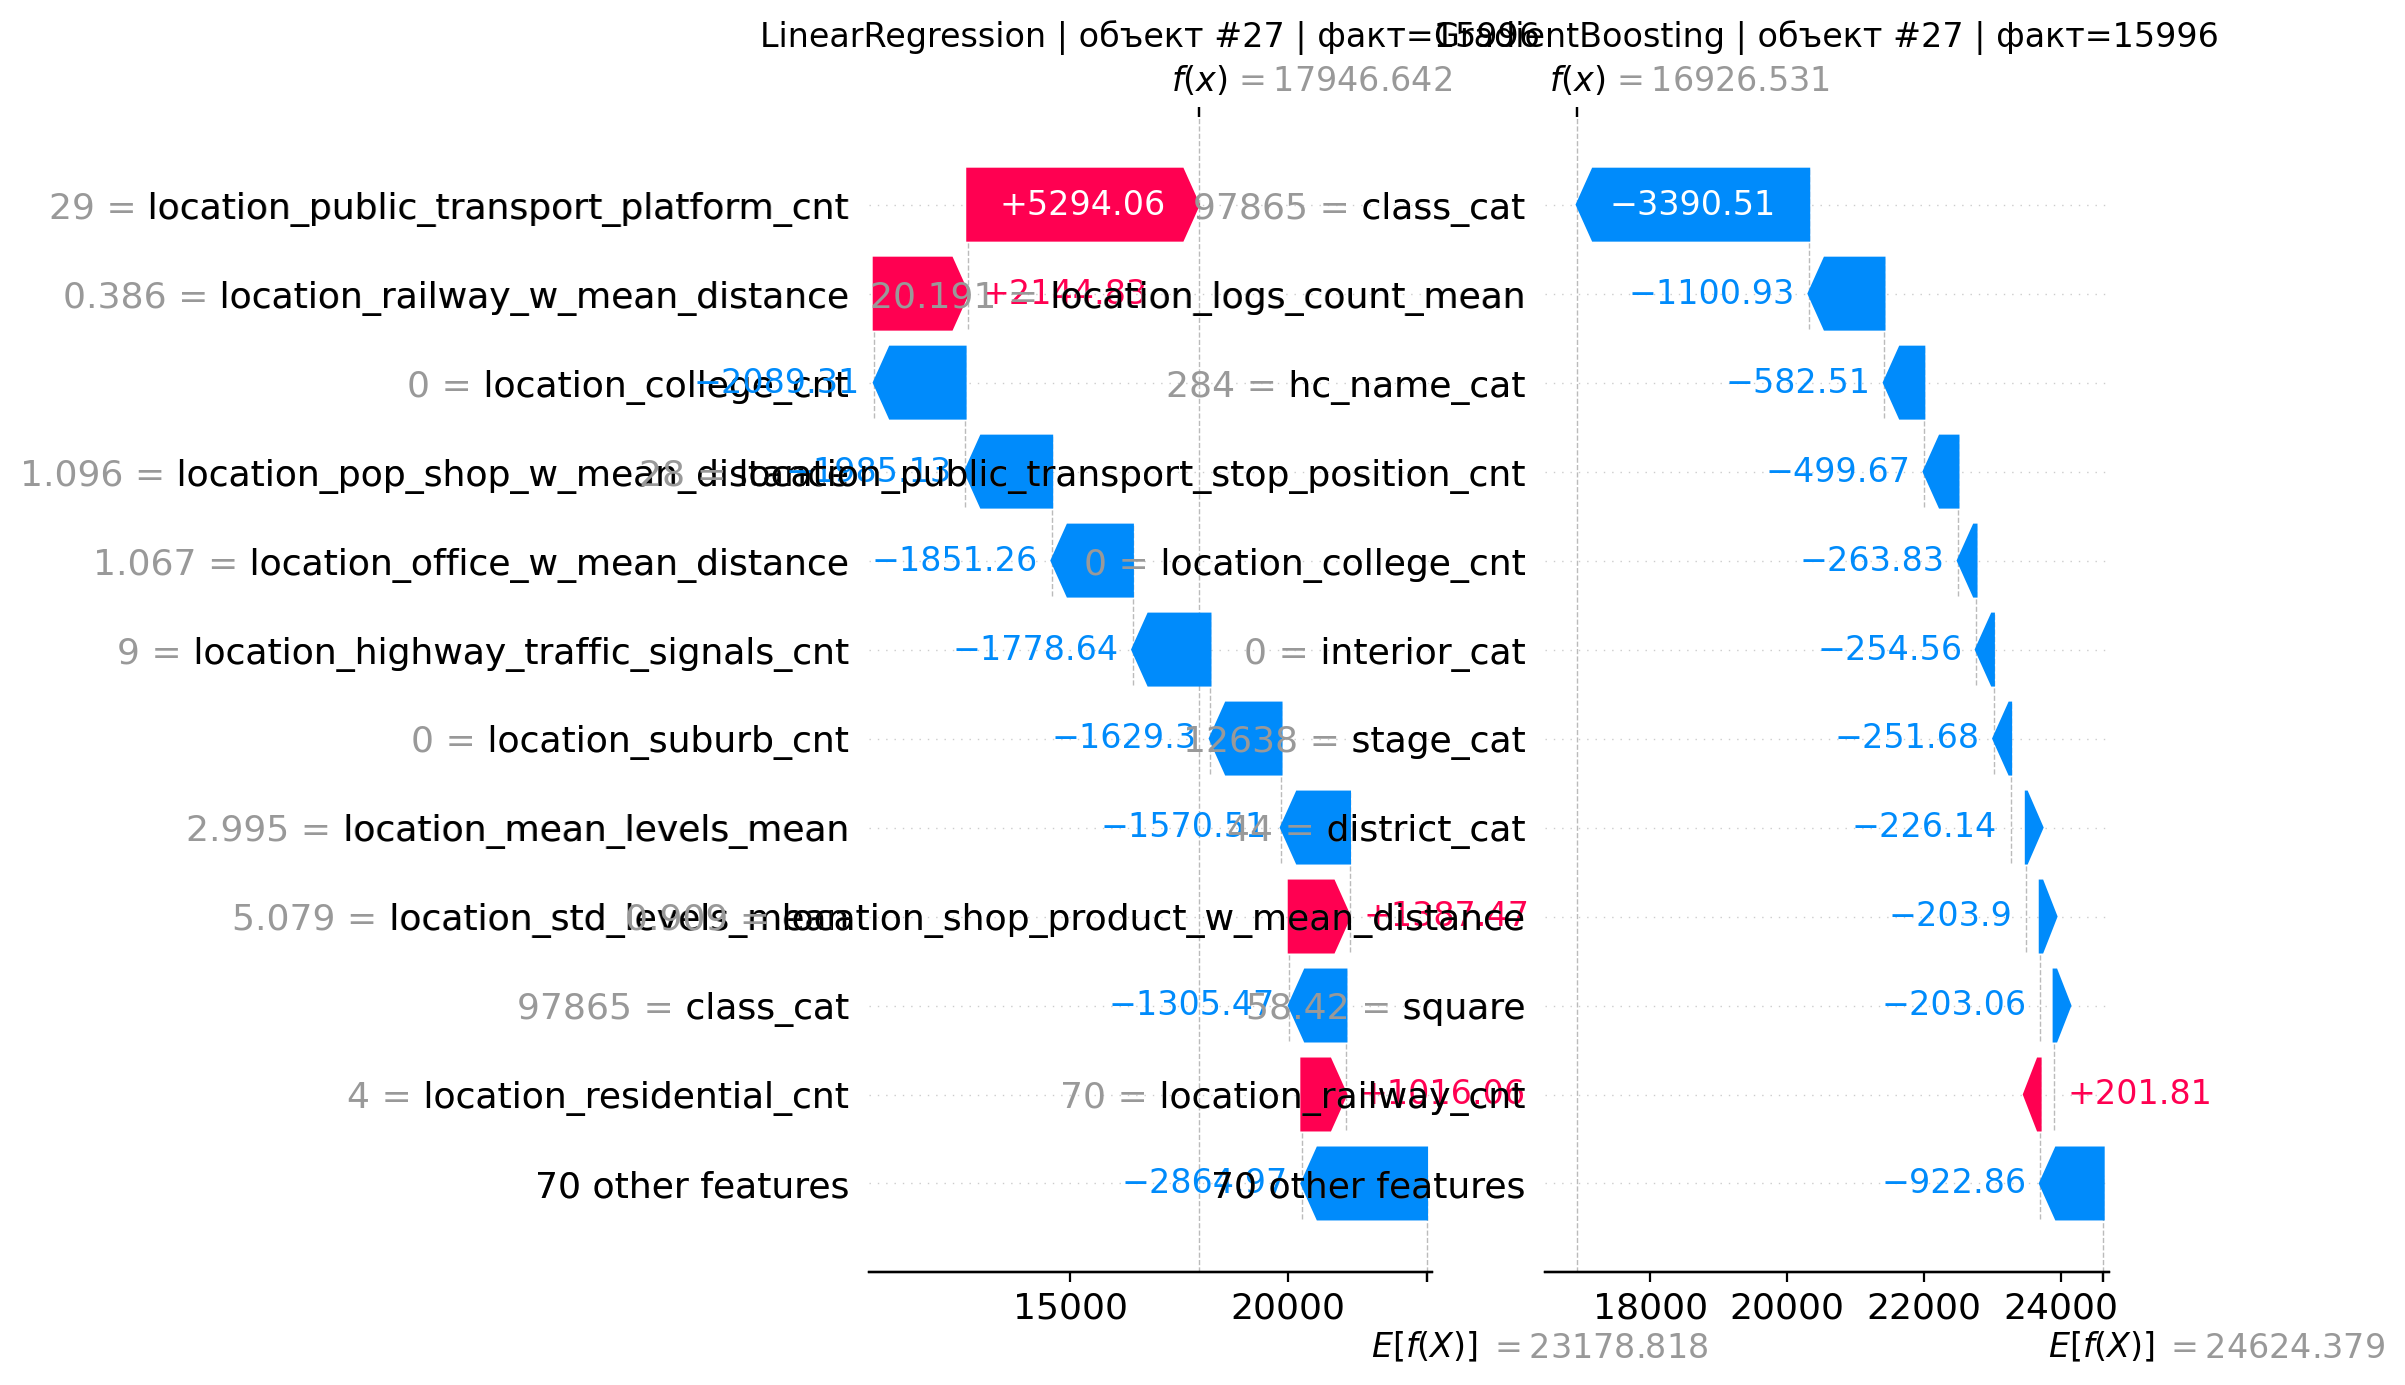

In [80]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
plt.sca(axes[0])
shap.plots.waterfall(sv_lr[0], max_display=12, show=False)
axes[0].set_title(f"LinearRegression | объект #{IDX} | факт={y_test.iloc[IDX]:.0f}")
plt.sca(axes[1])
shap.plots.waterfall(sv_gb[0], max_display=12, show=False)
axes[1].set_title(f"GradientBoosting | объект #{IDX} | факт={y_test.iloc[IDX]:.0f}")
plt.tight_layout()
plt.show()


Объект #27 — дешёвая квартира (факт 15996 руб/м2). Обе модели предсказывают ниже своей базы:
LR: 23179 − 5232 = 17947, GB: 24624 − 7698 = 16927. То есть SHAP "разбирает" разрыв
между средним объектом обучающей выборки и нашей точкой по признакам.

LR. Самый сильный вклад положительный: location_public_transport_platform_cnt (+5294),
он почти один тянет предсказание вверх. Дальше — десяток мелких отрицательных вкладов
(college_cnt, pop_shop, office, suburb, levels_mean), каждый по 1.5–2k. Class_cat у LR
далеко не лидер (−1305, 10-е место), хотя в Permutation Importance и Beta-Importance для GB
он был №1. Для LR это нормально: коэффициенты линейной регрессии перераспределены
между десятками скоррелированных локационных признаков.

GB. Здесь картина совсем другая: class_cat доминирует с огромным отрывом (−3391),
дальше уже мелочи (logs_count_mean, hc_name_cat, public_transport_stop). То же самое
мы видели в Permutation Importance, Beta-Importance и в LIME для объекта #0 —
бустинг сосредоточил всю информацию о цене в class_cat, остальные признаки
работают как тонкая корректировка.

Локальные SHAP двух моделей дают разные истории про один и тот же объект: LR говорит
"тут хорошая транспортная доступность, но локация в целом плоховатая", GB говорит
"низкий класс жилья — и всё, остальное мелочи". Это не противоречие, а разные точки
зрения двух моделей на одни данные.

Проверка SHAP-разложения: base + сумма по фи = prediction для обеих моделей с точностью до рубля,
SHAP действительно полностью объясняет предсказание (это его главное свойство — efficiency).
